---
## Modulo 0 — Setup y Taxonomia del Machine Learning

### Taxonomia de Machine Learning
```
Machine Learning
+-- Supervisado  (tiene etiquetas y)
|   +-- Regresion      -> y continua  (precio, salario, ventas)
|   +-- Clasificacion  -> y discreta  (churn: si/no, spam, diagnostico)
|
+-- No Supervisado  (sin etiquetas)
|   +-- Clustering           -> K-Means, DBSCAN, hierarchical
|   +-- Reduccion de Dim     -> PCA, UMAP, t-SNE
|   +-- Deteccion de anomalias -> IsolationForest
|
+-- Refuerzo  (agente + entorno + recompensa)
    -> Q-learning, PPO, AlphaGo
```

### Notacion estandar
- **n** = numero de observaciones (filas del dataset)
- **p** = numero de features (columnas / variables predictoras)
- **X** in R^{nxp} = matriz de diseno (features)
- **y** in R^n = vector objetivo (target / label)
- **yhat** = predicciones del modelo
- **theta** (o **w**, **beta**) = parametros a aprender
- **L(theta)** = funcion de perdida (loss function)
- **eps** = error irreducible (ruido del mundo real)

### Flujo de un proyecto de ML
```
Datos crudos -> EDA -> Preprocesamiento -> Train/Test Split
             -> Seleccion de modelo -> Entrenamiento
             -> Evaluacion (CV) -> Ajuste de HP -> Evaluacion final
             -> Serializacion -> Despliegue en produccion -> Monitoreo
```

> No existe un algoritmo universalmente optimo para todos los problemas.
> La seleccion del modelo depende de la estructura de los datos.


In [6]:
# ============================================================
# IMPORTS GLOBALES — ejecutar esta celda primero
# ============================================================
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import re, json, pickle

# --- Preprocesamiento y seleccion ---
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      StratifiedKFold, RandomizedSearchCV,
                                      GridSearchCV, learning_curve)
from sklearn.preprocessing import (StandardScaler, MinMaxScaler,
                                    LabelEncoder, OneHotEncoder)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# --- Modelos supervisados ---
from sklearn.linear_model import (LinearRegression, LogisticRegression,
                                   Ridge, Lasso, ElasticNet)
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                               GradientBoostingClassifier, AdaBoostClassifier,
                               VotingClassifier)
from sklearn.svm import SVC, SVR
from sklearn import tree as sktree

# --- Modelos no supervisados ---
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# --- Metricas ---
from sklearn.metrics import (accuracy_score, confusion_matrix,
                               classification_report, roc_curve, auc,
                               mean_squared_error, r2_score,
                               precision_recall_curve, f1_score,
                               ConfusionMatrixDisplay,
                               precision_score, recall_score)

# --- NLP ---
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB

# --- Distribucion de scipy ---
from scipy.stats import randint, uniform

# --- XGBoost (opcional) ---
try:
    import xgboost as xgb
    BOOSTING_AVAILABLE = True
    print("XGBoost disponible")
except ImportError:
    BOOSTING_AVAILABLE = False
    print("XGBoost no disponible: pip install xgboost")

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('tab10')
print("Imports completados correctamente")


XGBoost disponible
Imports completados correctamente


---
## Modulo 1 — Analisis Exploratorio de Datos (EDA)

El EDA es el primer paso **obligatorio** antes de cualquier modelo.
Su objetivo: **entender la estructura, calidad y relaciones** en los datos.

### Checklist EDA
1. `shape`, `dtypes` — forma y tipos de datos
2. Valores faltantes (missings)
3. Estadisticas descriptivas (`describe`)
4. Distribucion de la variable objetivo — **desbalanceo de clases?**
5. Distribucion de cada feature (histogramas, boxplots)
6. Correlaciones (heatmap de Pearson)
7. Deteccion de outliers (z-score, IQR)

> **Dataset principal:** `Churn_Modelling.csv`
> Predecir si un cliente de banco abandona su cuenta (`Exited = 1`).
> n=10,000, p=14 (despues de limpieza: 10 features utiles)


In [7]:
# --- Cargar y explorar el dataset ---
df = pd.read_csv('./Data/Churn_Modelling.csv')


print("=" * 55)
print(f"  Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print("=" * 55)
df.head()


  Dimensiones: 10,000 filas x 14 columnas


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
print("Tipos de datos:")
print(df.dtypes.to_string())
print()
print("Estadisticas descriptivas:")
df.describe().round(2)


Tipos de datos:
RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64

Estadisticas descriptivas:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0
mean,5000.50,15690940.57,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2
std,2886.90,71936.19,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4
min,1.00,15565701.00,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,2500.75,15628528.25,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0
50%,5000.50,15690738.00,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0
75%,7500.25,15753233.75,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0
max,10000.00,15815690.00,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0


In [9]:
# --- Valores faltantes ---
missing = df.isnull().sum()
pct     = (missing / len(df) * 100).round(2)
mdf     = pd.DataFrame({'Count': missing, 'Pct (%)': pct})
mdf_nonzero = mdf[mdf['Count'] > 0]
if len(mdf_nonzero) > 0:
    print(mdf_nonzero.to_string())
else:
    print("No hay valores faltantes en este dataset.")


No hay valores faltantes en este dataset.


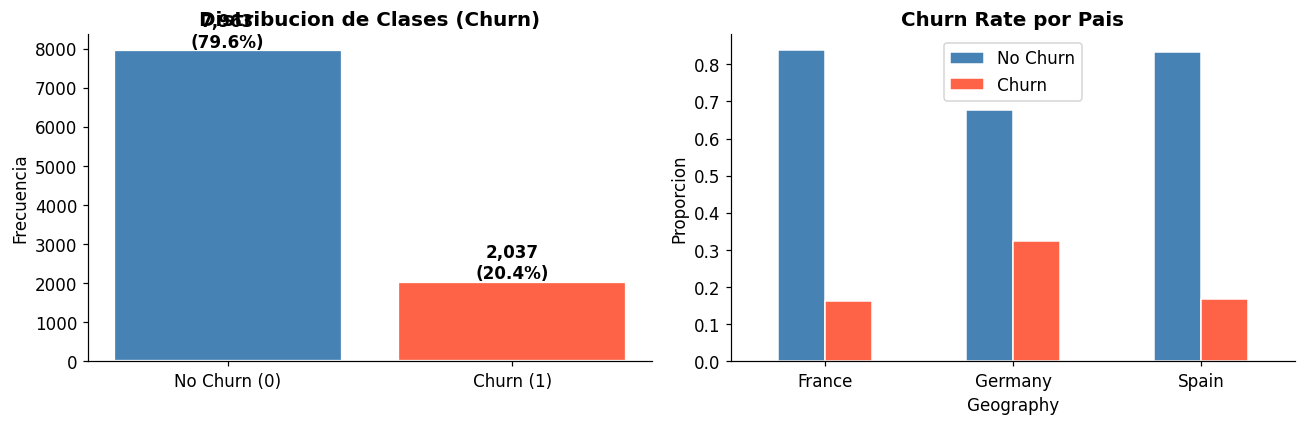

ALERTA: Solo 20.4% de los clientes tienen churn = 1
-> Dato desbalanceado: usar stratify en split y metricas F1, AUC (no solo accuracy)


In [10]:
# --- Distribucion de la variable objetivo (target) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tc = df['Exited'].value_counts()
axes[0].bar(['No Churn (0)', 'Churn (1)'], tc.values,
            color=['steelblue', 'tomato'], edgecolor='white', linewidth=1.5)
for i, v in enumerate(tc.values):
    axes[0].text(i, v + 80, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold')
axes[0].set_title('Distribucion de Clases (Churn)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Frecuencia')

pd.crosstab(df['Geography'], df['Exited'], normalize='index').plot(
    kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='white', rot=0)
axes[1].set_title('Churn Rate por Pais', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Proporcion'); axes[1].legend(['No Churn', 'Churn'])

plt.tight_layout()
plt.savefig('eda_target.png', bbox_inches='tight')
plt.show()

print(f"ALERTA: Solo {tc[1]/len(df)*100:.1f}% de los clientes tienen churn = 1")
print("-> Dato desbalanceado: usar stratify en split y metricas F1, AUC (no solo accuracy)")


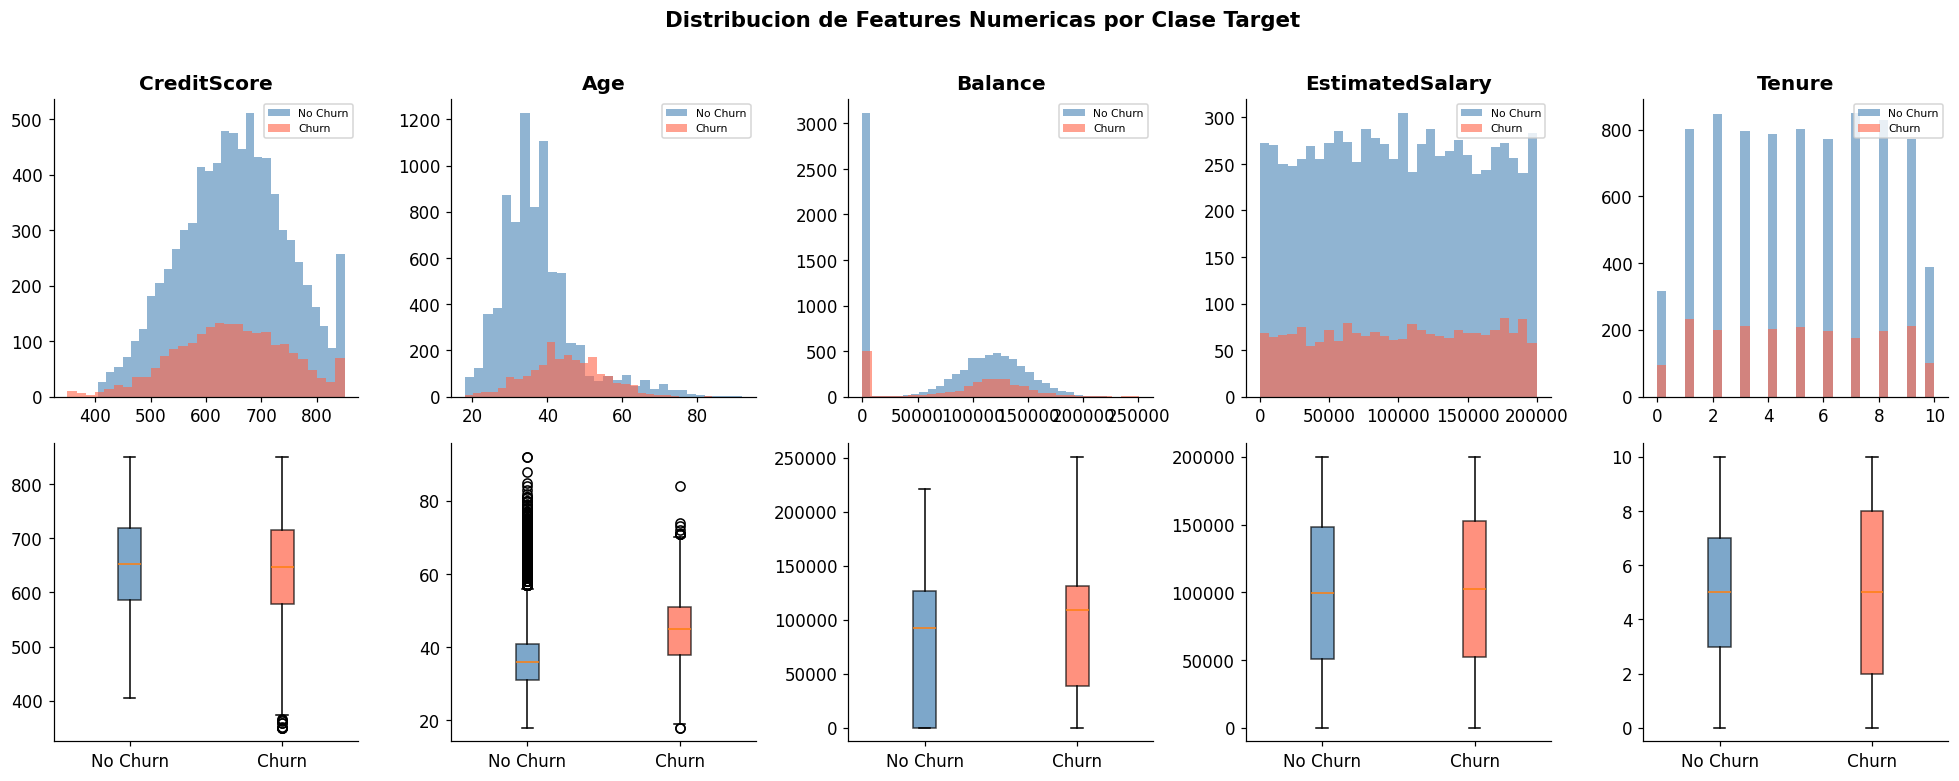

In [11]:
# --- Distribuciones de features numericas por clase ---
num_cols_eda = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'Tenure']

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for i, col in enumerate(num_cols_eda):
    axes[0, i].hist(df[df['Exited']==0][col], bins=30, alpha=0.6,
                    label='No Churn', color='steelblue')
    axes[0, i].hist(df[df['Exited']==1][col], bins=30, alpha=0.6,
                    label='Churn', color='tomato')
    axes[0, i].set_title(col, fontweight='bold')
    axes[0, i].legend(fontsize=7)

    bp = axes[1, i].boxplot(
        [df[df['Exited']==0][col].dropna(), df[df['Exited']==1][col].dropna()],
        patch_artist=True, labels=['No Churn', 'Churn']
    )
    for patch, color in zip(bp['boxes'], ['steelblue', 'tomato']):
        patch.set_facecolor(color); patch.set_alpha(0.7)

plt.suptitle('Distribucion de Features Numericas por Clase Target',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_numeric.png', bbox_inches='tight')
plt.show()


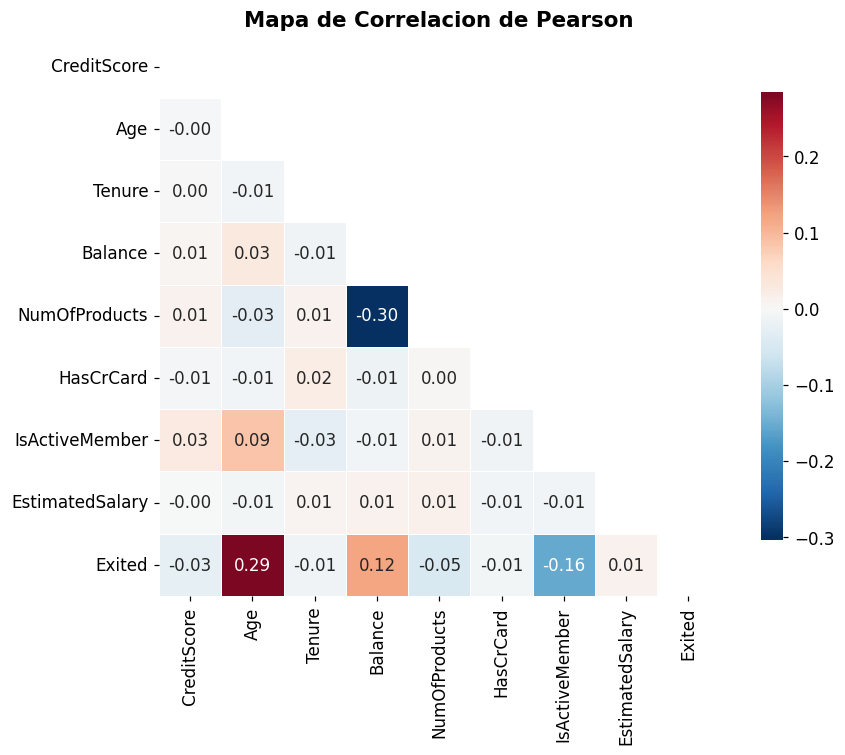

Correlaciones con Exited (target):
Age                0.285323
Balance            0.118533
EstimatedSalary    0.012097
HasCrCard         -0.007138
Tenure            -0.014001
CreditScore       -0.027094
NumOfProducts     -0.047820
IsActiveMember    -0.156128


In [12]:
# --- Mapa de correlacion de Pearson ---
fig, ax = plt.subplots(figsize=(9, 7))
corr_cols = ['CreditScore', 'Age', 'Tenure', 'Balance',
             'NumOfProducts', 'HasCrCard', 'IsActiveMember',
             'EstimatedSalary', 'Exited']
corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Mapa de Correlacion de Pearson', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_corr.png', bbox_inches='tight')
plt.show()

print("Correlaciones con Exited (target):")
print(corr_matrix['Exited'].drop('Exited').sort_values(ascending=False).to_string())


In [14]:
# --- Deteccion de outliers con z-score ---
print("Outliers (|z| > 3) por columna numerica:")
print(f"  {'Columna':<20} {'N outliers':>12} {'Pct (%)':>10}")
print("-" * 45)
for col in ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']:
    z = np.abs(stats.zscore(df[col].dropna()))
    n_out = (z > 3).sum()
    pct = n_out / len(df) * 100
    print(f"  {col:<20} {n_out:>12} {pct:>10.2f}")

print()
print("Regla IQR: outlier si x < Q1 - 1.5*IQR  o  x > Q3 + 1.5*IQR")
print("Con datos bancarios los outliers suelen ser clientes anómalos — cuidado al eliminarlos")


Outliers (|z| > 3) por columna numerica:
  Columna                N outliers    Pct (%)
---------------------------------------------
  CreditScore                     8       0.08
  Age                           133       1.33
  Balance                         0       0.00
  EstimatedSalary                 0       0.00

Regla IQR: outlier si x < Q1 - 1.5*IQR  o  x > Q3 + 1.5*IQR
Con datos bancarios los outliers suelen ser clientes anómalos — cuidado al eliminarlos


---
## Modulo 2 — Preprocesamiento y Feature Engineering

### Tipos de preprocesamiento

| Tecnica | Formula | Cuando usarla |
|---------|---------|---------------|
| **Imputacion media** | x_miss = mean(x_train) | Numerica, faltantes aleatorios (MCAR) |
| **Imputacion mediana** | x_miss = median(x_train) | Numerica, datos con outliers |
| **Imputacion moda** | x_miss = mode(x_train) | Categorica |
| **One-Hot Encoding** | 0/1 por categoria | Categorica nominal (sin orden) |
| **Ordinal Encoding** | entero segun orden | Categorica ordinal (bajo/medio/alto) |
| **StandardScaler** | z = (x - mu) / sigma | LR, SVM, PCA, KNN |
| **MinMaxScaler** | z = (x - min) / (max - min) | Redes neuronales, K-Means |
| **Log-transform** | z = log(x + 1) | Distribuciones muy sesgadas |

### Regla de oro
> **`fit()` SOLO con datos de entrenamiento.**
> `transform()` se aplica a train Y test usando los parametros del train.

### Por que escalar?
Algoritmos como LR, SVM y KNN computan distancias o gradientes.
Sin escalar, una feature con valores grandes (salario: 100,000) domina sobre
una pequena (edad: 30), **distorsionando el aprendizaje**.
Los arboles y Random Forest NO necesitan escalado.


In [15]:
# --- Preparacion del dataset Churn ---
drop_cols = ['RowNumber', 'CustomerId', 'Surname']
df_clean = df.drop(columns=drop_cols)

X = df_clean.drop('Exited', axis=1)
y = df_clean['Exited']

# Definir tipos de columnas
cat_cols = ['Geography', 'Gender']
bin_cols = ['HasCrCard', 'IsActiveMember']
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance',
            'NumOfProducts', 'EstimatedSalary']

print("Columnas categoricas:", cat_cols)
print("Columnas binarias   :", bin_cols)
print("Columnas numericas  :", num_cols)
print(f"Dimension X: {X.shape}")


Columnas categoricas: ['Geography', 'Gender']
Columnas binarias   : ['HasCrCard', 'IsActiveMember']
Columnas numericas  : ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
Dimension X: (10000, 10)


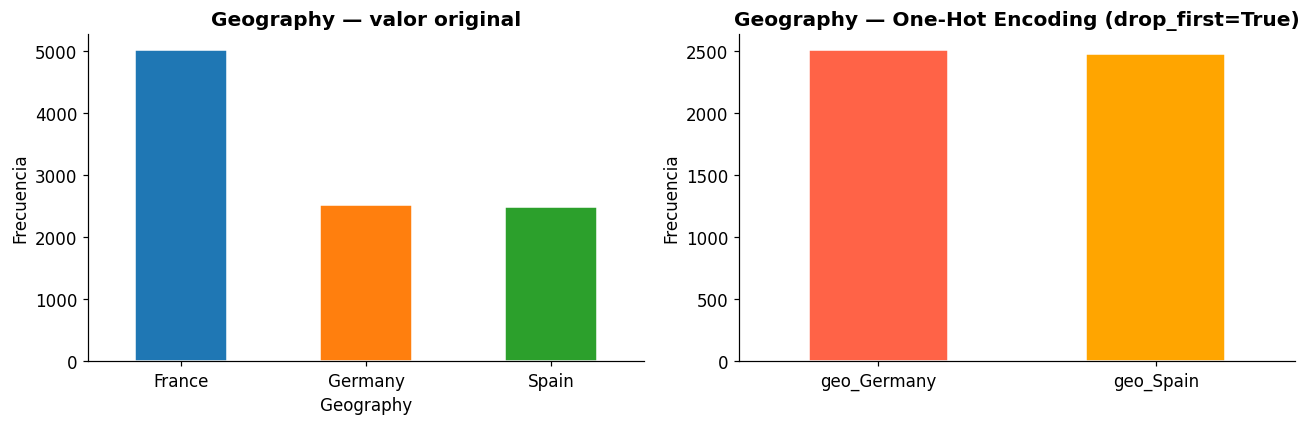

Con 3 categorias (France, Germany, Spain):
  OHE crea 2 dummies (drop_first): geo_Germany, geo_Spain
  France = 0,0 (referencia). Esto EVITA multicolinealidad perfecta (dummy trap).


In [16]:
# --- One-Hot Encoding: antes vs despues ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Antes
df['Geography'].value_counts().plot(kind='bar', ax=axes[0],
    color=sns.color_palette('tab10', 3), edgecolor='white', rot=0)
axes[0].set_title('Geography — valor original', fontweight='bold')
axes[0].set_ylabel('Frecuencia')

# Despues (OHE con drop_first=True para evitar dummy trap)
geo_dummies = pd.get_dummies(df['Geography'], prefix='geo', drop_first=True)
geo_dummies.sum().plot(kind='bar', ax=axes[1], color=['tomato','orange'],
                       rot=0, edgecolor='white')
axes[1].set_title('Geography — One-Hot Encoding (drop_first=True)', fontweight='bold')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('preprocessing_ohe.png', bbox_inches='tight')
plt.show()

print("Con 3 categorias (France, Germany, Spain):")
print("  OHE crea 2 dummies (drop_first): geo_Germany, geo_Spain")
print("  France = 0,0 (referencia). Esto EVITA multicolinealidad perfecta (dummy trap).")


In [17]:
# --- ColumnTransformer: el pipeline correcto en sklearn ---
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,    num_cols),
    ('cat', categorical_transformer, cat_cols),
    ('bin', 'passthrough',           bin_cols)
])

# --- Split estratificado (SIEMPRE stratify en clasificacion desbalanceada) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} obs | Test: {X_test.shape[0]:,} obs")
print(f"Churn rate -> Train: {y_train.mean():.3f} | Test: {y_test.mean():.3f}")
print("stratify=y garantiza la misma proporcion de clases en ambos splits")


Train: 8,000 obs | Test: 2,000 obs
Churn rate -> Train: 0.204 | Test: 0.203
stratify=y garantiza la misma proporcion de clases en ambos splits


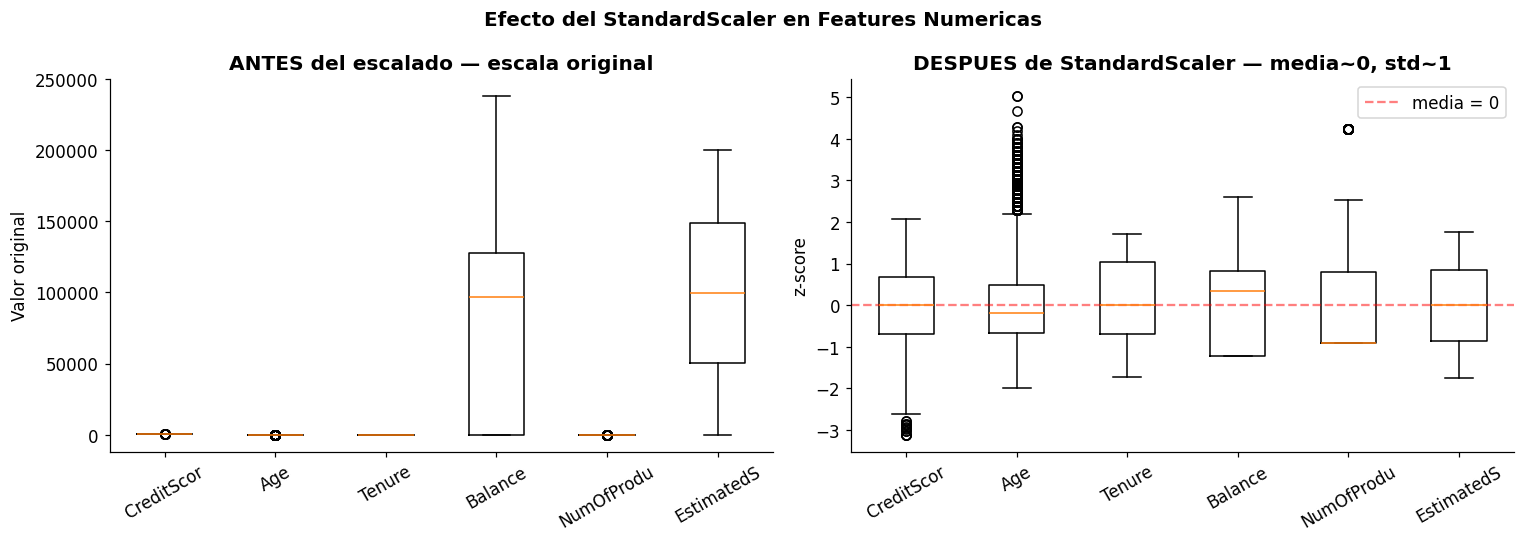

Features procesadas finales: 11
(6 numericas + 3 OHE + 2 binarias = 11 features)


In [18]:
# --- Visualizar efecto del StandardScaler ---
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

ohe_feats = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(cat_cols).tolist()
feature_names = num_cols + ohe_feats + bin_cols

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes del escalado
axes[0].boxplot([X_train[c].dropna().values for c in num_cols],
                labels=[c[:10] for c in num_cols], vert=True)
axes[0].set_title('ANTES del escalado — escala original', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylabel('Valor original')

# Despues del escalado
axes[1].boxplot([X_train_proc[:, i] for i in range(len(num_cols))],
                labels=[c[:10] for c in num_cols], vert=True)
axes[1].set_title('DESPUES de StandardScaler — media~0, std~1', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5, label='media = 0')
axes[1].set_ylabel('z-score'); axes[1].legend()

plt.suptitle('Efecto del StandardScaler en Features Numericas',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('preprocessing_scale.png', bbox_inches='tight')
plt.show()

print(f"Features procesadas finales: {X_train_proc.shape[1]}")
print("(6 numericas + 3 OHE + 2 binarias = 11 features)")


---
## Modulo 3 — Data Leakage: El Error Mas Costoso

### Que es Data Leakage?

> **Data leakage** ocurre cuando informacion del conjunto de **test** (o del futuro)
> contamina el proceso de entrenamiento, produciendo metricas artificialmente infladas
> que **no se replican en produccion**.

### Tipos de leakage
1. **Leakage de preprocesamiento** — ajustar imputer/scaler con todo el dataset (incluye test)
2. **Leakage temporal** — usar datos del futuro para predecir el pasado (muy comun en finanzas)
3. **Leakage de target** — incluir features directamente derivadas del target
4. **Leakage en CV** — escalar antes de la validacion cruzada sin usar Pipeline

### La regla de oro:
```
fit()       ->  SOLO con datos de train (aprende mu, sigma, medias, etc.)
transform() ->  train + test (aplica la transformacion aprendida del train)
```

### Impacto real
Un modelo con leakage reporta **AUC = 0.98** en backtesting,
pero solo **AUC = 0.62** en produccion.
La diferencia es data leakage.

### Solucion: sklearn.Pipeline
Cuando usas `Pipeline` + `cross_val_score`, sklearn automaticamente
hace `fit()` solo en el fold de entrenamiento de cada iteracion.


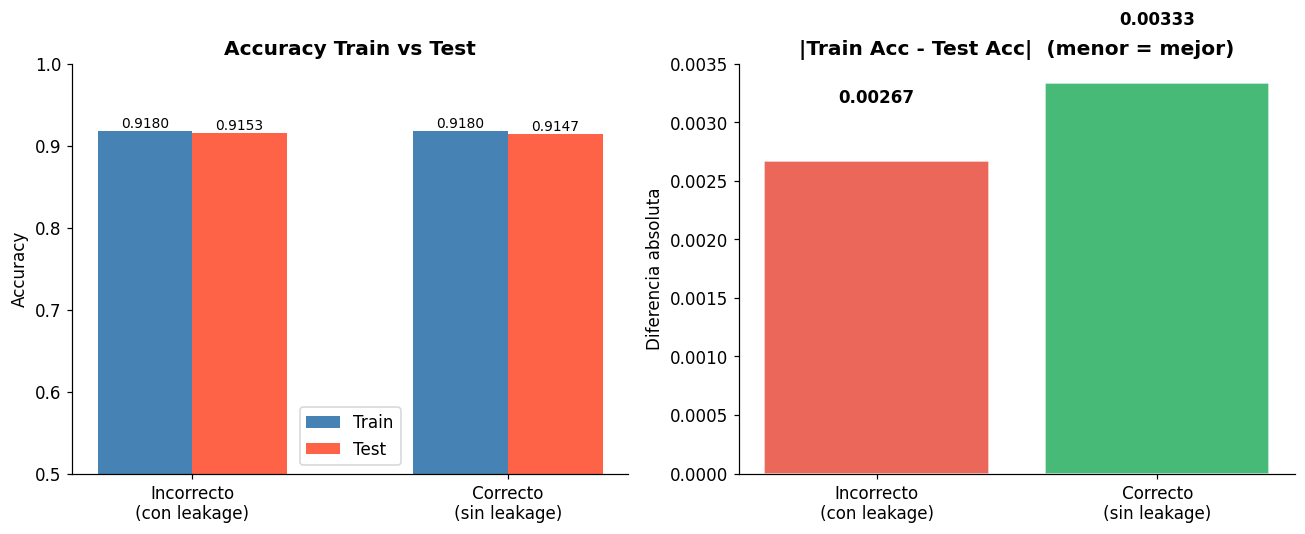

RESULTADOS:
                                    Train     Test      Gap
  Incorrecto (con leakage)         0.9180   0.9153  0.00267
  Correcto   (sin leakage)         0.9180   0.9147  0.00333

SOLUCION: sklearn.Pipeline garantiza que fit() del scaler/imputer
NUNCA ve el test set durante la validacion cruzada.


In [19]:
# --- Demostracion cuantitativa: Data Leakage vs Pipeline correcto ---
np.random.seed(42)
n = 5000

X1 = np.random.normal(2.0, 1.0, n)
X2 = np.random.normal(-1.0, 2.0, n)
X3 = np.random.rand(n)

# Introducir missings en X1 (15%) y X2 (10%)
X1[np.random.choice(n, int(0.15*n), replace=False)] = np.nan
X2[np.random.choice(n, int(0.10*n), replace=False)] = np.nan

# Generar y con logica logistica
logits = (0.8*np.nan_to_num(X1, nan=2.0)
          - 1.2*np.nan_to_num(X2, nan=-1.0)
          + 2.0*X3
          + np.random.normal(0, 0.5, n))
p_dl = 1 / (1 + np.exp(-logits))
y_dl = np.random.binomial(1, p_dl)

df_dl = pd.DataFrame({'X1': X1, 'X2': X2, 'X3': X3, 'target': y_dl})
tr_dl, te_dl = train_test_split(df_dl, test_size=0.3, random_state=42,
                                 stratify=df_dl['target'])
Xtr_dl = tr_dl.drop('target', axis=1)
ytr_dl = tr_dl['target']
Xte_dl = te_dl.drop('target', axis=1)
yte_dl = te_dl['target']

# ==========================================================
# PIPELINE INCORRECTO: usa todo el dataset para fit
# ==========================================================
X_all_dl = pd.concat([Xtr_dl, Xte_dl]).reset_index(drop=True)
imp_bad  = SimpleImputer(strategy='mean').fit(X_all_dl)   # LEAKAGE!
scl_bad  = StandardScaler().fit(imp_bad.transform(X_all_dl))  # LEAKAGE!

Xtr_bad = scl_bad.transform(imp_bad.transform(Xtr_dl))
Xte_bad = scl_bad.transform(imp_bad.transform(Xte_dl))
m_bad   = LogisticRegression(max_iter=1000).fit(Xtr_bad, ytr_dl)
acc_bad_tr = accuracy_score(ytr_dl, m_bad.predict(Xtr_bad))
acc_bad_te = accuracy_score(yte_dl, m_bad.predict(Xte_bad))

# ==========================================================
# PIPELINE CORRECTO: fit solo con train
# ==========================================================
imp_ok = SimpleImputer(strategy='mean').fit(Xtr_dl)       # CORRECTO
scl_ok = StandardScaler().fit(imp_ok.transform(Xtr_dl))   # CORRECTO

Xtr_ok = scl_ok.transform(imp_ok.transform(Xtr_dl))
Xte_ok = scl_ok.transform(imp_ok.transform(Xte_dl))
m_ok   = LogisticRegression(max_iter=1000).fit(Xtr_ok, ytr_dl)
acc_ok_tr = accuracy_score(ytr_dl, m_ok.predict(Xtr_ok))
acc_ok_te = accuracy_score(yte_dl, m_ok.predict(Xte_ok))

# --- Visualizacion ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x_ = np.arange(2); w = 0.3
labels = ['Incorrecto\n(con leakage)', 'Correcto\n(sin leakage)']
bar1 = axes[0].bar(x_-w/2, [acc_bad_tr, acc_ok_tr], w, label='Train', color='steelblue')
bar2 = axes[0].bar(x_+w/2, [acc_bad_te, acc_ok_te], w, label='Test',  color='tomato')
axes[0].set_xticks(x_); axes[0].set_xticklabels(labels)
axes[0].set_ylim([0.5, 1.0]); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy Train vs Test', fontweight='bold'); axes[0].legend()
for b in list(bar1)+list(bar2):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.004,
                 f'{b.get_height():.4f}', ha='center', fontsize=9)

gap_bad = abs(acc_bad_tr - acc_bad_te)
gap_ok  = abs(acc_ok_tr  - acc_ok_te)
axes[1].bar(labels, [gap_bad, gap_ok],
            color=['#e74c3c', '#27ae60'], alpha=0.85, edgecolor='white')
axes[1].set_title('|Train Acc - Test Acc|  (menor = mejor)', fontweight='bold')
axes[1].set_ylabel('Diferencia absoluta')
for i, v in enumerate([gap_bad, gap_ok]):
    axes[1].text(i, v+0.0005, f'{v:.5f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('data_leakage.png', bbox_inches='tight')
plt.show()

print("RESULTADOS:")
print(f"  {'':30} {'Train':>8} {'Test':>8} {'Gap':>8}")
print(f"  {'Incorrecto (con leakage)':30} {acc_bad_tr:>8.4f} {acc_bad_te:>8.4f} {gap_bad:>8.5f}")
print(f"  {'Correcto   (sin leakage)':30} {acc_ok_tr:>8.4f} {acc_ok_te:>8.4f} {gap_ok:>8.5f}")
print()
print("SOLUCION: sklearn.Pipeline garantiza que fit() del scaler/imputer")
print("NUNCA ve el test set durante la validacion cruzada.")


---
## Modulo 4 — Regresion Lineal y Regresion Logistica

---
### 4.1 Regresion Lineal

**Modelo:**
$$\hat{y} = \theta_0 + \theta_1 x_1 + \cdots + \theta_p x_p = X\boldsymbol{\theta}$$

**Funcion de perdida — MSE (Mean Squared Error):**
$$\mathcal{L}(\theta) = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

**Solucion analitica (OLS — Ordinary Least Squares):**
$$\hat{\theta} = (X^T X)^{-1} X^T y$$
Existe solo si X'X es invertible (no hay multicolinealidad perfecta).

**Supuestos de Gauss-Markov (para que OLS sea BLUE: Best Linear Unbiased Estimator):**
1. Linealidad en los parametros: y = X*theta + eps
2. Media condicional cero: E[eps|X] = 0  (exogeneidad)
3. Homocedasticidad: Var(eps|X) = sigma^2  (varianza constante)
4. No autocorrelacion: Cov(eps_i, eps_j) = 0
5. No multicolinealidad perfecta

**Metricas de evaluacion en regresion:**
- **MSE** = (1/n) sum (y - yhat)^2
- **RMSE** = sqrt(MSE) — en las mismas unidades que y
- **MAE** = (1/n) sum |y - yhat|
- **R2** = 1 - SS_res/SS_tot  (proporcion de varianza explicada, 0 a 1)

---
### 4.2 Regresion Logistica

Para y binaria (0/1), la regresion lineal puede predecir valores fuera de [0,1].
Solucion: aplicar la **funcion logistica (sigmoid)** al output lineal:

$$\sigma(z) = \frac{1}{1 + e^{-z}}, \quad z = X\boldsymbol{\theta}$$

$$P(y=1 \mid X) = \sigma(X\theta)$$

**Funcion de perdida — Binary Cross-Entropy (log-loss):**
$$\mathcal{L}(\theta) = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)\right]$$

Se optimiza con gradiente descendente o metodos quasi-Newton (L-BFGS).
Parametro de regularizacion: **C** (inverso de lambda en sklearn).


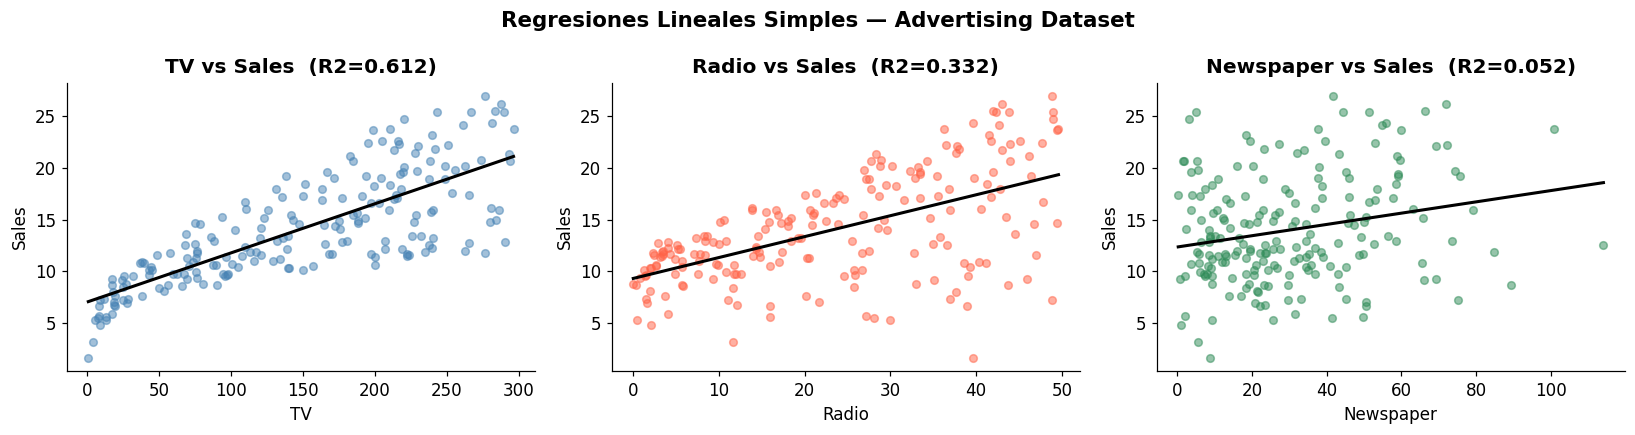

In [21]:
# --- 4.1 Regresion Lineal Simple — Advertising dataset ---
ads = pd.read_csv('./Data/Advertising.csv', index_col=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
feats_ads = ['TV', 'Radio', 'Newspaper']
colors_ads = ['steelblue', 'tomato', 'seagreen']

for i, (feat, col) in enumerate(zip(feats_ads, colors_ads)):
    axes[i].scatter(ads[feat], ads['Sales'], alpha=0.5, color=col, s=25)
    m_simple = LinearRegression().fit(ads[[feat]], ads['Sales'])
    xr = np.linspace(ads[feat].min(), ads[feat].max(), 200).reshape(-1, 1)
    axes[i].plot(xr, m_simple.predict(xr), 'k-', lw=2)
    r2 = r2_score(ads['Sales'], m_simple.predict(ads[[feat]]))
    axes[i].set_title(f'{feat} vs Sales  (R2={r2:.3f})', fontweight='bold')
    axes[i].set_xlabel(feat); axes[i].set_ylabel('Sales')

plt.suptitle('Regresiones Lineales Simples — Advertising Dataset',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('linreg_scatter.png', bbox_inches='tight')
plt.show()


REGRESION LINEAL MULTIPLE — Advertising
  Intercepto       : 14.100
  beta(TV          ):   3.7642
  beta(Radio       ):   2.7923
  beta(Newspaper   ):   0.0560
  RMSE Train: 1.645 | RMSE Test: 1.782
  R2   Train: 0.8957 | R2   Test: 0.8994

Interpretacion (con StandardScaler):
  beta_TV    > 0: mas inversion en TV -> mas ventas
  beta_Radio > 0: mas inversion en Radio -> mas ventas
  beta_Newspaper ~0: Newspaper no agrega valor marginal


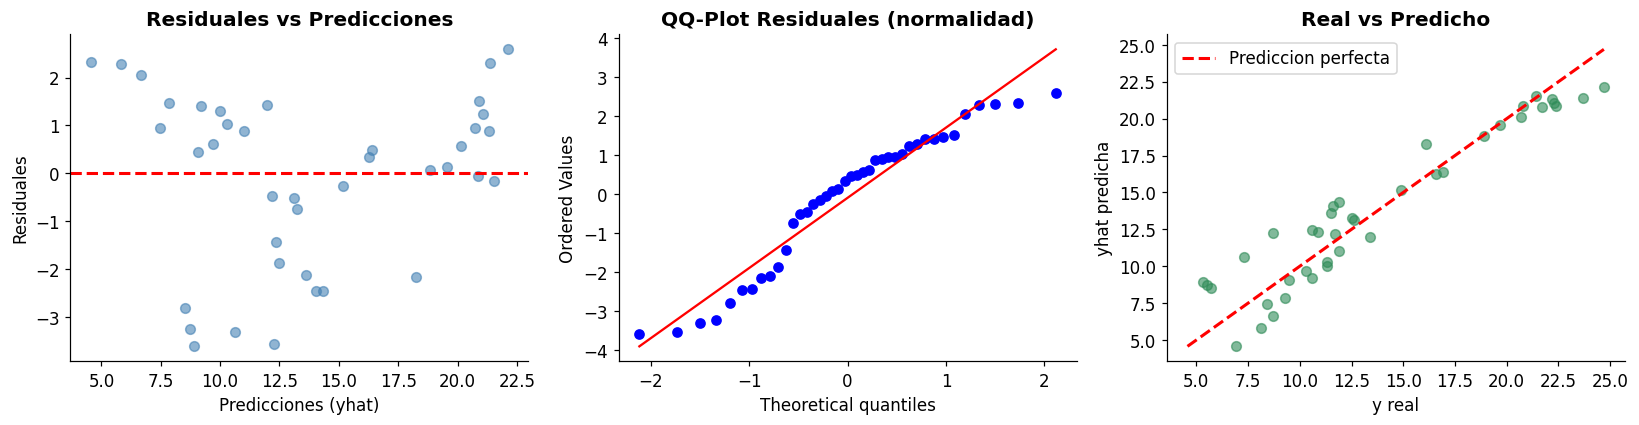

In [22]:
# --- Regresion lineal multiple con diagnostico de residuales ---
Xads = ads[['TV', 'Radio', 'Newspaper']]
yads = ads['Sales']

Xads_tr, Xads_te, yads_tr, yads_te = train_test_split(
    Xads, yads, test_size=0.2, random_state=42)

scl_ads   = StandardScaler().fit(Xads_tr)
Xads_trs  = scl_ads.transform(Xads_tr)
Xads_tes  = scl_ads.transform(Xads_te)

lr_ads = LinearRegression().fit(Xads_trs, yads_tr)
yhat_tr_ads = lr_ads.predict(Xads_trs)
yhat_te_ads = lr_ads.predict(Xads_tes)

rmse_tr_ads = np.sqrt(mean_squared_error(yads_tr, yhat_tr_ads))
rmse_te_ads = np.sqrt(mean_squared_error(yads_te, yhat_te_ads))
r2_tr_ads   = r2_score(yads_tr, yhat_tr_ads)
r2_te_ads   = r2_score(yads_te, yhat_te_ads)

print("REGRESION LINEAL MULTIPLE — Advertising")
print(f"  Intercepto       : {lr_ads.intercept_:.3f}")
for feat, coef in zip(['TV', 'Radio', 'Newspaper'], lr_ads.coef_):
    print(f"  beta({feat:<12}): {coef:>8.4f}")
print(f"  RMSE Train: {rmse_tr_ads:.3f} | RMSE Test: {rmse_te_ads:.3f}")
print(f"  R2   Train: {r2_tr_ads:.4f} | R2   Test: {r2_te_ads:.4f}")
print()
print("Interpretacion (con StandardScaler):")
print("  beta_TV    > 0: mas inversion en TV -> mas ventas")
print("  beta_Radio > 0: mas inversion en Radio -> mas ventas")
print("  beta_Newspaper ~0: Newspaper no agrega valor marginal")

# Graficos de diagnostico de residuales
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
residuals_ads = yads_te - yhat_te_ads

# 1. Residuales vs Predicciones
axes[0].scatter(yhat_te_ads, residuals_ads, alpha=0.6, color='steelblue', s=40)
axes[0].axhline(0, color='red', lw=2, ls='--')
axes[0].set_xlabel('Predicciones (yhat)'); axes[0].set_ylabel('Residuales')
axes[0].set_title('Residuales vs Predicciones', fontweight='bold')
# patron aleatorio = homocedasticidad OK

# 2. QQ-plot de residuales (normalidad)
stats.probplot(residuals_ads, dist='norm', plot=axes[1])
axes[1].set_title('QQ-Plot Residuales (normalidad)', fontweight='bold')

# 3. Real vs Predicho
mn = min(yads_te.min(), yhat_te_ads.min())
mx = max(yads_te.max(), yhat_te_ads.max())
axes[2].scatter(yads_te, yhat_te_ads, alpha=0.6, color='seagreen', s=40)
axes[2].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Prediccion perfecta')
axes[2].set_xlabel('y real'); axes[2].set_ylabel('yhat predicha')
axes[2].set_title('Real vs Predicho', fontweight='bold'); axes[2].legend()

plt.tight_layout()
plt.savefig('linreg_diagnostics.png', bbox_inches='tight')
plt.show()


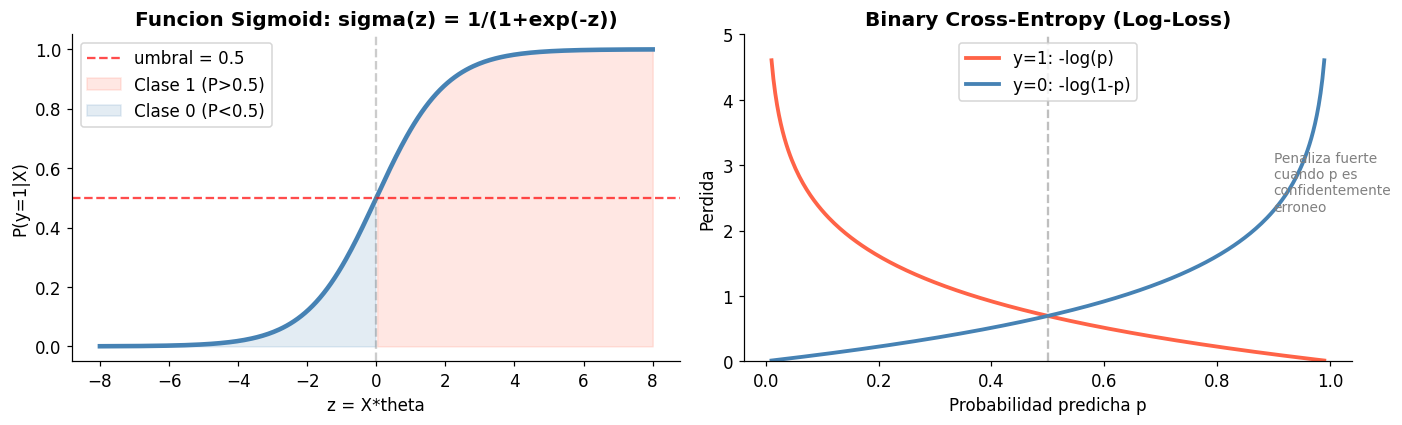

In [23]:
# --- 4.2 Funcion Sigmoid y Log-Loss ---
z = np.linspace(-8, 8, 300)
sigmoid = 1 / (1 + np.exp(-z))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(z, sigmoid, 'steelblue', lw=3)
axes[0].axhline(0.5, color='red', ls='--', alpha=0.7, label='umbral = 0.5')
axes[0].axvline(0,   color='gray', ls='--', alpha=0.4)
axes[0].fill_between(z, sigmoid, 0, where=(z>=0), alpha=0.15, color='tomato', label='Clase 1 (P>0.5)')
axes[0].fill_between(z, sigmoid, 0, where=(z<0),  alpha=0.15, color='steelblue', label='Clase 0 (P<0.5)')
axes[0].set_title('Funcion Sigmoid: sigma(z) = 1/(1+exp(-z))', fontweight='bold')
axes[0].set_xlabel('z = X*theta'); axes[0].set_ylabel('P(y=1|X)')
axes[0].legend(); axes[0].set_ylim(-0.05, 1.05)

p_vals = np.linspace(0.01, 0.99, 300)
axes[1].plot(p_vals, -np.log(p_vals),   color='tomato',    lw=2.5, label='y=1: -log(p)')
axes[1].plot(p_vals, -np.log(1-p_vals), color='steelblue', lw=2.5, label='y=0: -log(1-p)')
axes[1].set_title('Binary Cross-Entropy (Log-Loss)', fontweight='bold')
axes[1].set_xlabel('Probabilidad predicha p'); axes[1].set_ylabel('Perdida')
axes[1].legend(); axes[1].set_ylim(0, 5)
axes[1].axvline(0.5, color='gray', ls='--', alpha=0.5)
axes[1].annotate('Penaliza fuerte\ncuando p es\nconfidentemente\nerroneo',
                  xy=(0.9, 2.3), fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('logistic_sigmoid.png', bbox_inches='tight')
plt.show()


In [24]:
# --- 4.3 Regresion Logistica en Churn ---
log_pipe = Pipeline(steps=[
    ('prep', preprocessor),
    ('clf',  LogisticRegression(max_iter=2000, random_state=42, C=1.0))
])
log_pipe.fit(X_train, y_train)

y_pred_lr  = log_pipe.predict(X_test)
y_proba_lr = log_pipe.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

print("REGRESION LOGISTICA — Churn Prediction")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"  F1-Score : {f1_score(y_test, y_pred_lr):.4f}")
print(f"  AUC-ROC  : {roc_auc_lr:.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))


REGRESION LOGISTICA — Churn Prediction
  Accuracy : 0.8080
  F1-Score : 0.2836
  AUC-ROC  : 0.7748

              precision    recall  f1-score   support

    No Churn       0.82      0.97      0.89      1593
       Churn       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



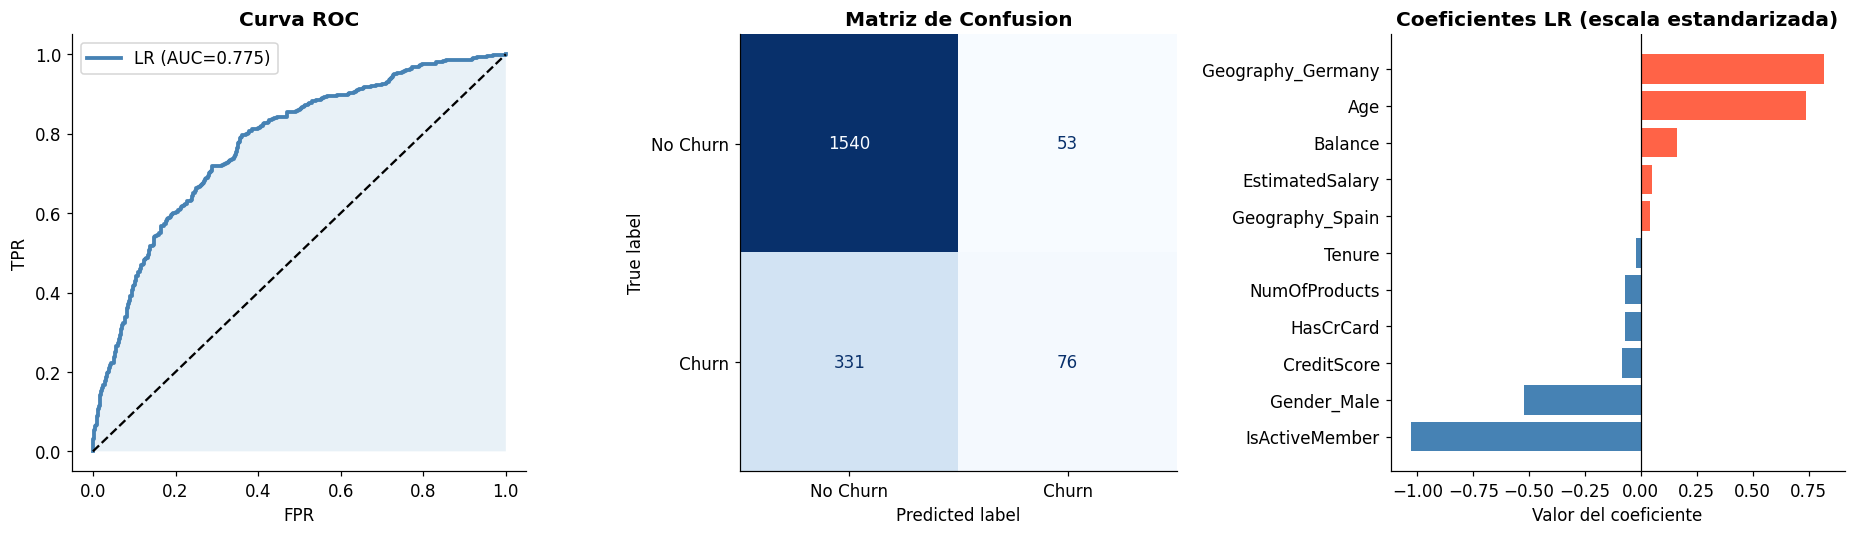

Interpretacion de coeficientes:
  Coef > 0 -> aumenta log-odds de Churn (odds ratio = exp(coef) > 1)
  Coef < 0 -> disminuye log-odds de Churn (odds ratio < 1)

Top features positivas (aumentan churn):
          Feature     Coef
Geography_Germany 0.819585
              Age 0.738453
          Balance 0.161093
Top features negativas (disminuyen churn):
       Feature      Coef
IsActiveMember -1.028157
   Gender_Male -0.523155
   CreditScore -0.085893


In [25]:
# ROC + Confusion Matrix + Coeficientes
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ROC
axes[0].plot(fpr_lr, tpr_lr, color='steelblue', lw=2.5, label=f'LR (AUC={roc_auc_lr:.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1.5); axes[0].fill_between(fpr_lr, tpr_lr, alpha=0.1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Curva ROC', fontweight='bold'); axes[0].legend()

# Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['No Churn', 'Churn']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de Confusion', fontweight='bold')

# Coeficientes
coefs_lr = log_pipe.named_steps['clf'].coef_[0]
ohe_feats_lr = log_pipe.named_steps['prep'].named_transformers_['cat']['onehot'].get_feature_names_out(cat_cols).tolist()
feat_names_lr = num_cols + ohe_feats_lr + bin_cols
coef_df = pd.DataFrame({'Feature': feat_names_lr, 'Coef': coefs_lr}).sort_values('Coef')
colors_c = ['tomato' if c > 0 else 'steelblue' for c in coef_df['Coef']]
axes[2].barh(coef_df['Feature'], coef_df['Coef'], color=colors_c)
axes[2].axvline(0, color='black', lw=0.8)
axes[2].set_title('Coeficientes LR (escala estandarizada)', fontweight='bold')
axes[2].set_xlabel('Valor del coeficiente')

plt.tight_layout()
plt.savefig('logistic_results.png', bbox_inches='tight')
plt.show()

print("Interpretacion de coeficientes:")
print("  Coef > 0 -> aumenta log-odds de Churn (odds ratio = exp(coef) > 1)")
print("  Coef < 0 -> disminuye log-odds de Churn (odds ratio < 1)")
print()
print("Top features positivas (aumentan churn):")
print(coef_df.tail(3)[['Feature','Coef']].sort_values('Coef', ascending=False).to_string(index=False))
print("Top features negativas (disminuyen churn):")
print(coef_df.head(3)[['Feature','Coef']].to_string(index=False))


---
## Modulo 5 — Bias-Variance Tradeoff y Regularizacion

### Descomposicion del error esperado

$$\mathbb{E}[(y - \hat{f}(x))^2] = \underbrace{\text{Bias}^2[\hat{f}(x)]}_{\text{subajuste}} + \underbrace{\text{Var}[\hat{f}(x)]}_{\text{sobreajuste}} + \underbrace{\sigma^2}_{\text{irreducible}}$$

| | Alto Bias (Underfitting) | Alta Varianza (Overfitting) |
|-|--------------------------|------------------------------|
| Sintoma | Error alto en TRAIN y TEST | Error bajo TRAIN, alto TEST |
| Causa | Modelo muy simple | Modelo muy complejo |
| Solucion | + features, + complejidad | + regularizacion, + datos |

### Regularizacion: controlar la varianza penalizando los coeficientes

**Ridge (L2):** penaliza la suma de cuadrados — shrinks coeficientes hacia cero
$$\mathcal{L}_{\text{Ridge}} = \text{MSE} + \lambda \sum_{j=1}^{p} \theta_j^2$$

**Lasso (L1):** penaliza la suma de valores absolutos — puede hacer coeficientes exactamente = 0
$$\mathcal{L}_{\text{Lasso}} = \text{MSE} + \lambda \sum_{j=1}^{p} |\theta_j|$$

**ElasticNet:** combinacion convexa de L1 y L2

**Hiperparametro lambda (alpha en sklearn):**
- alpha -> 0: sin regularizacion (OLS puro)
- alpha -> inf: todos los coeficientes = 0 (modelo nulo)

En sklearn LogisticRegression: **C = 1/lambda** (C grande = menos regularizacion)


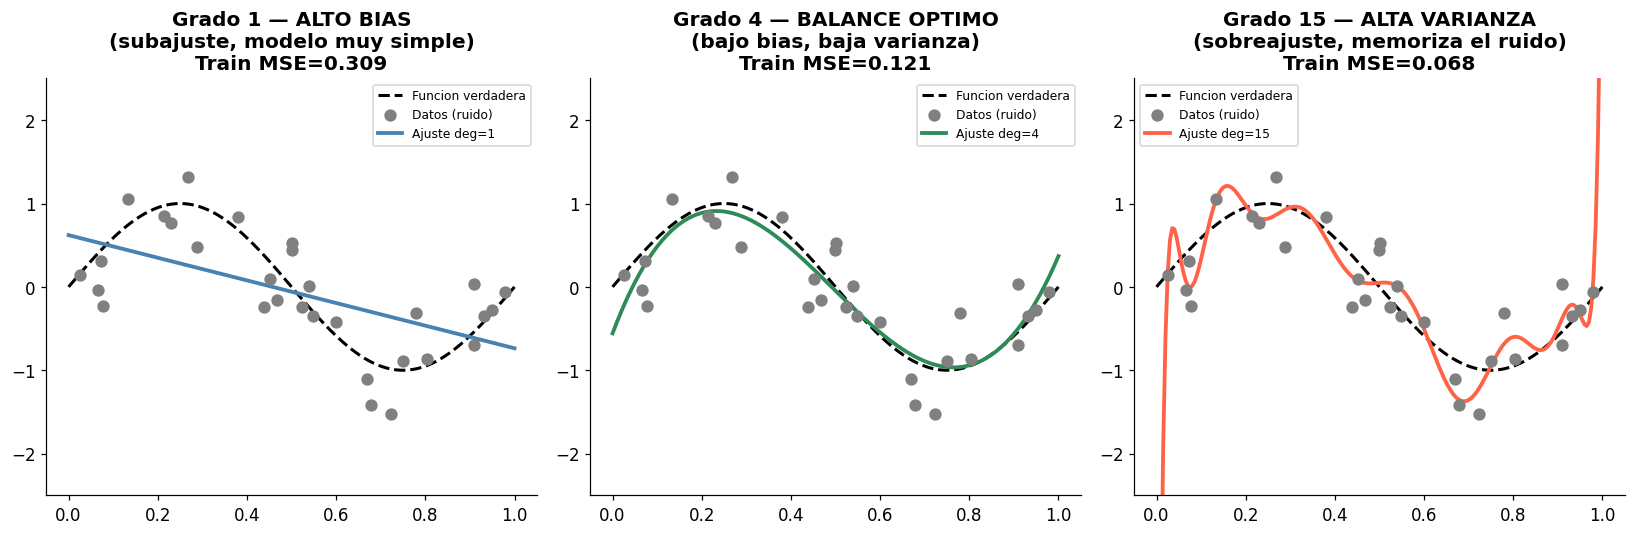

CLAVE:
  Grado 1:  alta bias  — no captura el patron sinusoidal
  Grado 4:  balance    — captura el patron sin memorizar el ruido
  Grado 15: alta varianza — memoriza cada punto, no generaliza


In [26]:
# --- Demostracion visual: Bias-Variance Tradeoff con polinomios ---
np.random.seed(7)
n_pts = 30
x_true = np.linspace(0, 1, 200)
y_true = np.sin(2 * np.pi * x_true)
x_sample = np.sort(np.random.rand(n_pts))
y_sample = np.sin(2 * np.pi * x_sample) + np.random.normal(0, 0.3, n_pts)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
degrees = [1, 4, 15]
titles  = ['Grado 1 — ALTO BIAS\n(subajuste, modelo muy simple)',
           'Grado 4 — BALANCE OPTIMO\n(bajo bias, baja varianza)',
           'Grado 15 — ALTA VARIANZA\n(sobreajuste, memoriza el ruido)']
colors_bv = ['steelblue', 'seagreen', 'tomato']

for ax, deg, title, col in zip(axes, degrees, titles, colors_bv):
    coeffs = np.polyfit(x_sample, y_sample, deg)
    y_fit  = np.polyval(coeffs, x_true)
    y_pred_s = np.polyval(coeffs, x_sample)
    train_mse = mean_squared_error(y_sample, y_pred_s)

    ax.plot(x_true, y_true, 'k--', lw=2, label='Funcion verdadera')
    ax.scatter(x_sample, y_sample, s=50, color='gray', zorder=5, label='Datos (ruido)')
    ax.plot(x_true, y_fit, color=col, lw=2.5, label=f'Ajuste deg={deg}')
    ax.set_title(f'{title}\nTrain MSE={train_mse:.3f}', fontweight='bold')
    ax.legend(fontsize=8); ax.set_ylim(-2.5, 2.5)

plt.tight_layout()
plt.savefig('bias_variance.png', bbox_inches='tight')
plt.show()

print("CLAVE:")
print("  Grado 1:  alta bias  — no captura el patron sinusoidal")
print("  Grado 4:  balance    — captura el patron sin memorizar el ruido")
print("  Grado 15: alta varianza — memoriza cada punto, no generaliza")


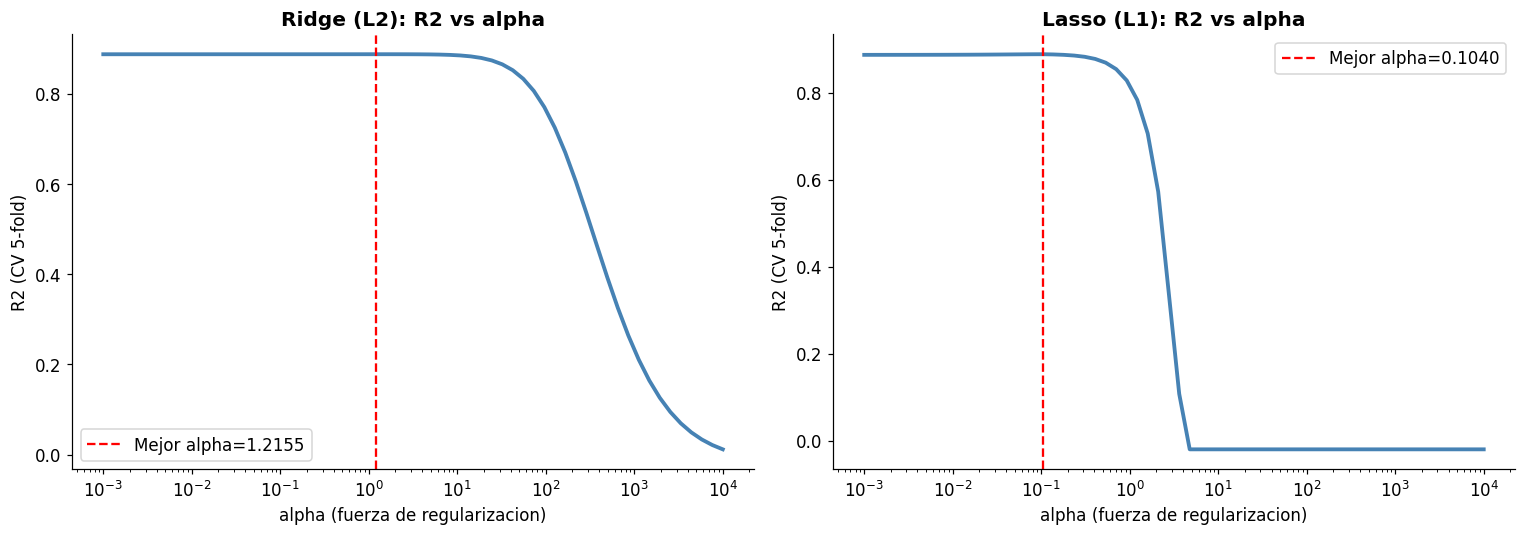

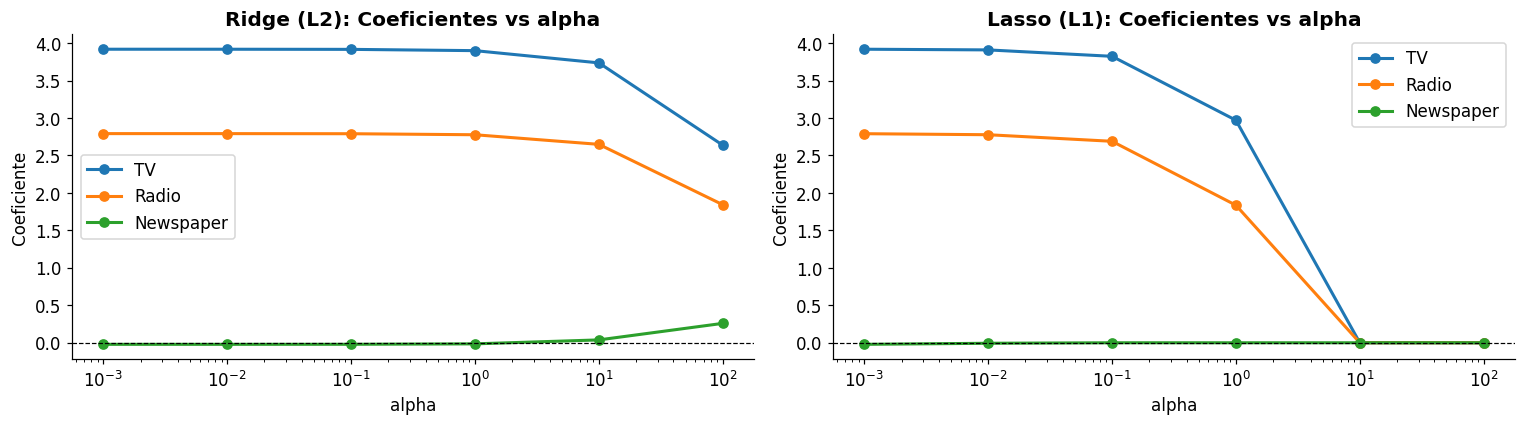

Observacion clave:
  Ridge: todos los coeficientes se reducen pero NUNCA llegan a 0
  Lasso: Newspaper llega a 0 con alpha grande -> seleccion automatica de variables


In [27]:
# --- Ridge vs Lasso: efecto de la regularizacion sobre R2 y coeficientes ---
alphas = np.logspace(-3, 4, 60)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, ModelClass) in zip(axes, [('Ridge (L2)', Ridge), ('Lasso (L1)', Lasso)]):
    r2_cv_vals = []
    for a in alphas:
        pipe_reg = Pipeline([('scl', StandardScaler()),
                             ('mdl', ModelClass(alpha=a, max_iter=20000))])
        cv_r2 = cross_val_score(pipe_reg, Xads, yads, cv=5, scoring='r2')
        r2_cv_vals.append(cv_r2.mean())

    best_a_reg = alphas[np.argmax(r2_cv_vals)]
    ax.semilogx(alphas, r2_cv_vals, color='steelblue', lw=2.5)
    ax.axvline(best_a_reg, color='red', ls='--', label=f'Mejor alpha={best_a_reg:.4f}')
    ax.set_xlabel('alpha (fuerza de regularizacion)')
    ax.set_ylabel('R2 (CV 5-fold)')
    ax.set_title(f'{name}: R2 vs alpha', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('regularization_r2.png', bbox_inches='tight')
plt.show()

# --- Efecto en coeficientes: Ridge shrinks, Lasso anula ---
Xads_scaled = StandardScaler().fit_transform(Xads)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
alphas_plot = [0.001, 0.01, 0.1, 1, 10, 100]

for ax, (name, ModelClass) in zip(axes, [('Ridge (L2)', Ridge), ('Lasso (L1)', Lasso)]):
    coef_matrix = []
    for a in alphas_plot:
        m_reg = ModelClass(alpha=a, max_iter=20000).fit(Xads_scaled, yads)
        coef_matrix.append(m_reg.coef_)
    coef_matrix = np.array(coef_matrix)
    for j, feat in enumerate(['TV', 'Radio', 'Newspaper']):
        ax.plot(alphas_plot, coef_matrix[:, j], 'o-', lw=2, label=feat)
    ax.set_xscale('log'); ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_xlabel('alpha'); ax.set_ylabel('Coeficiente')
    ax.set_title(f'{name}: Coeficientes vs alpha', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('regularization_coefs.png', bbox_inches='tight')
plt.show()

print("Observacion clave:")
print("  Ridge: todos los coeficientes se reducen pero NUNCA llegan a 0")
print("  Lasso: Newspaper llega a 0 con alpha grande -> seleccion automatica de variables")


---
## Modulo 6 — Arboles de Decision

### Como construye splits un arbol?

En cada nodo, el algoritmo busca el **umbral y la feature** que mas reduce la impureza:

$$\text{Ganancia} = I(\text{parent}) - \left[\frac{n_L}{n} I(L) + \frac{n_R}{n} I(R)\right]$$

### Metricas de impureza

**Gini Impurity** (default en sklearn):
$$G = 1 - \sum_{k=1}^{K} p_k^2$$

**Entropia (Ganancia de Informacion):**
$$H = -\sum_{k=1}^{K} p_k \log_2(p_k)$$

- Nodo puro (1 sola clase): G=0, H=0
- Nodo maxima mezcla (50/50 binario): G=0.5, H=1.0

### Hiperparametros clave
| Parametro | Efecto | Bias | Varianza |
|-----------|--------|------|----------|
| `max_depth` bajo | arbol pequeno | alto | baja |
| `max_depth` alto | arbol profundo | bajo | alta |
| `min_samples_leaf` alto | hojas con mas datos | algo mayor | mucho menor |
| `min_samples_split` alto | splits mas restrictivos | algo mayor | menor |

### Ventajas y desventajas
- Ventajas: interpretable, no requiere escalado, maneja variables mixtas, captura interacciones
- Desventajas: alta varianza (inestable), propenso a sobreajuste con max_depth libre


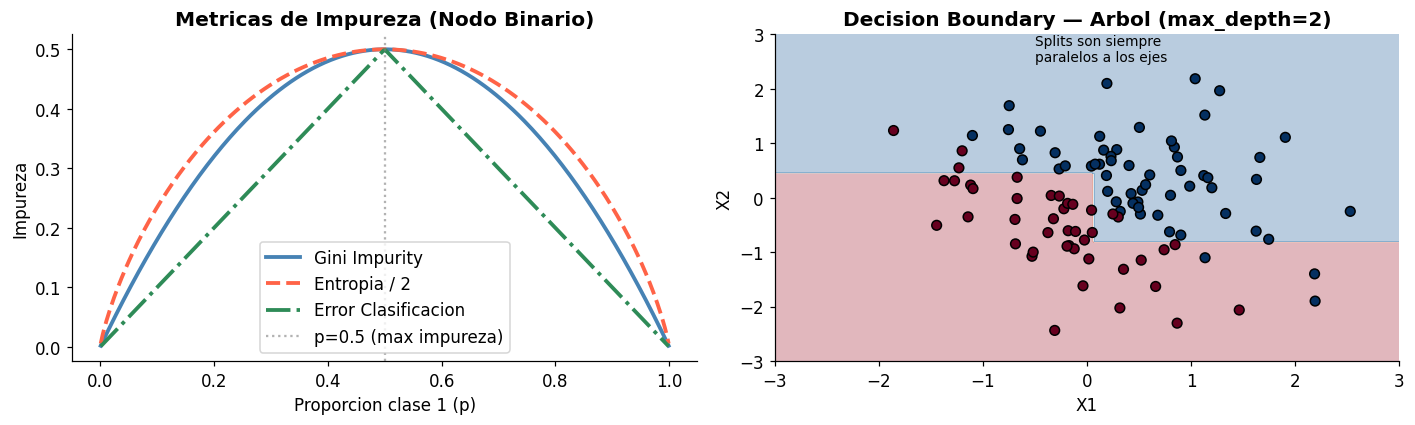

In [28]:
# --- Visualizacion de metricas de impureza ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

p = np.linspace(0.001, 0.999, 300)
gini    = 1 - p**2 - (1-p)**2
entropy = -(p * np.log2(p) + (1-p) * np.log2(1-p))
mc_err  = np.minimum(p, 1-p)

axes[0].plot(p, gini,      label='Gini Impurity',   color='steelblue', lw=2.5)
axes[0].plot(p, entropy/2, label='Entropia / 2',    color='tomato',    lw=2.5, ls='--')
axes[0].plot(p, mc_err,    label='Error Clasificacion', color='seagreen',  lw=2.5, ls='-.')
axes[0].axvline(0.5, color='gray', ls=':', alpha=0.6, label='p=0.5 (max impureza)')
axes[0].set_xlabel('Proporcion clase 1 (p)')
axes[0].set_ylabel('Impureza')
axes[0].set_title('Metricas de Impureza (Nodo Binario)', fontweight='bold')
axes[0].legend()

# Ejemplo de split
np.random.seed(1)
X_tree_ex = np.random.randn(100, 2)
y_tree_ex = (X_tree_ex[:,0] + X_tree_ex[:,1] > 0).astype(int)

dt_ex = DecisionTreeClassifier(max_depth=2, random_state=42).fit(X_tree_ex, y_tree_ex)
xx_t, yy_t = np.meshgrid(np.linspace(-3,3,200), np.linspace(-3,3,200))
Z_t = dt_ex.predict(np.c_[xx_t.ravel(), yy_t.ravel()]).reshape(xx_t.shape)
axes[1].contourf(xx_t, yy_t, Z_t, alpha=0.3, cmap='RdBu')
axes[1].scatter(X_tree_ex[:,0], X_tree_ex[:,1], c=y_tree_ex, cmap='RdBu',
                edgecolors='k', s=40, zorder=5)
axes[1].set_title('Decision Boundary — Arbol (max_depth=2)', fontweight='bold')
axes[1].set_xlabel('X1'); axes[1].set_ylabel('X2')
axes[1].annotate('Splits son siempre\nparalelos a los ejes', xy=(-0.5, 2.5), fontsize=9)

plt.tight_layout()
plt.savefig('tree_impurity.png', bbox_inches='tight')
plt.show()


ARBOL DE DECISION (max_depth=4) — Churn
  Accuracy : 0.8505
  F1-Score : 0.5335
  AUC-ROC  : 0.8216


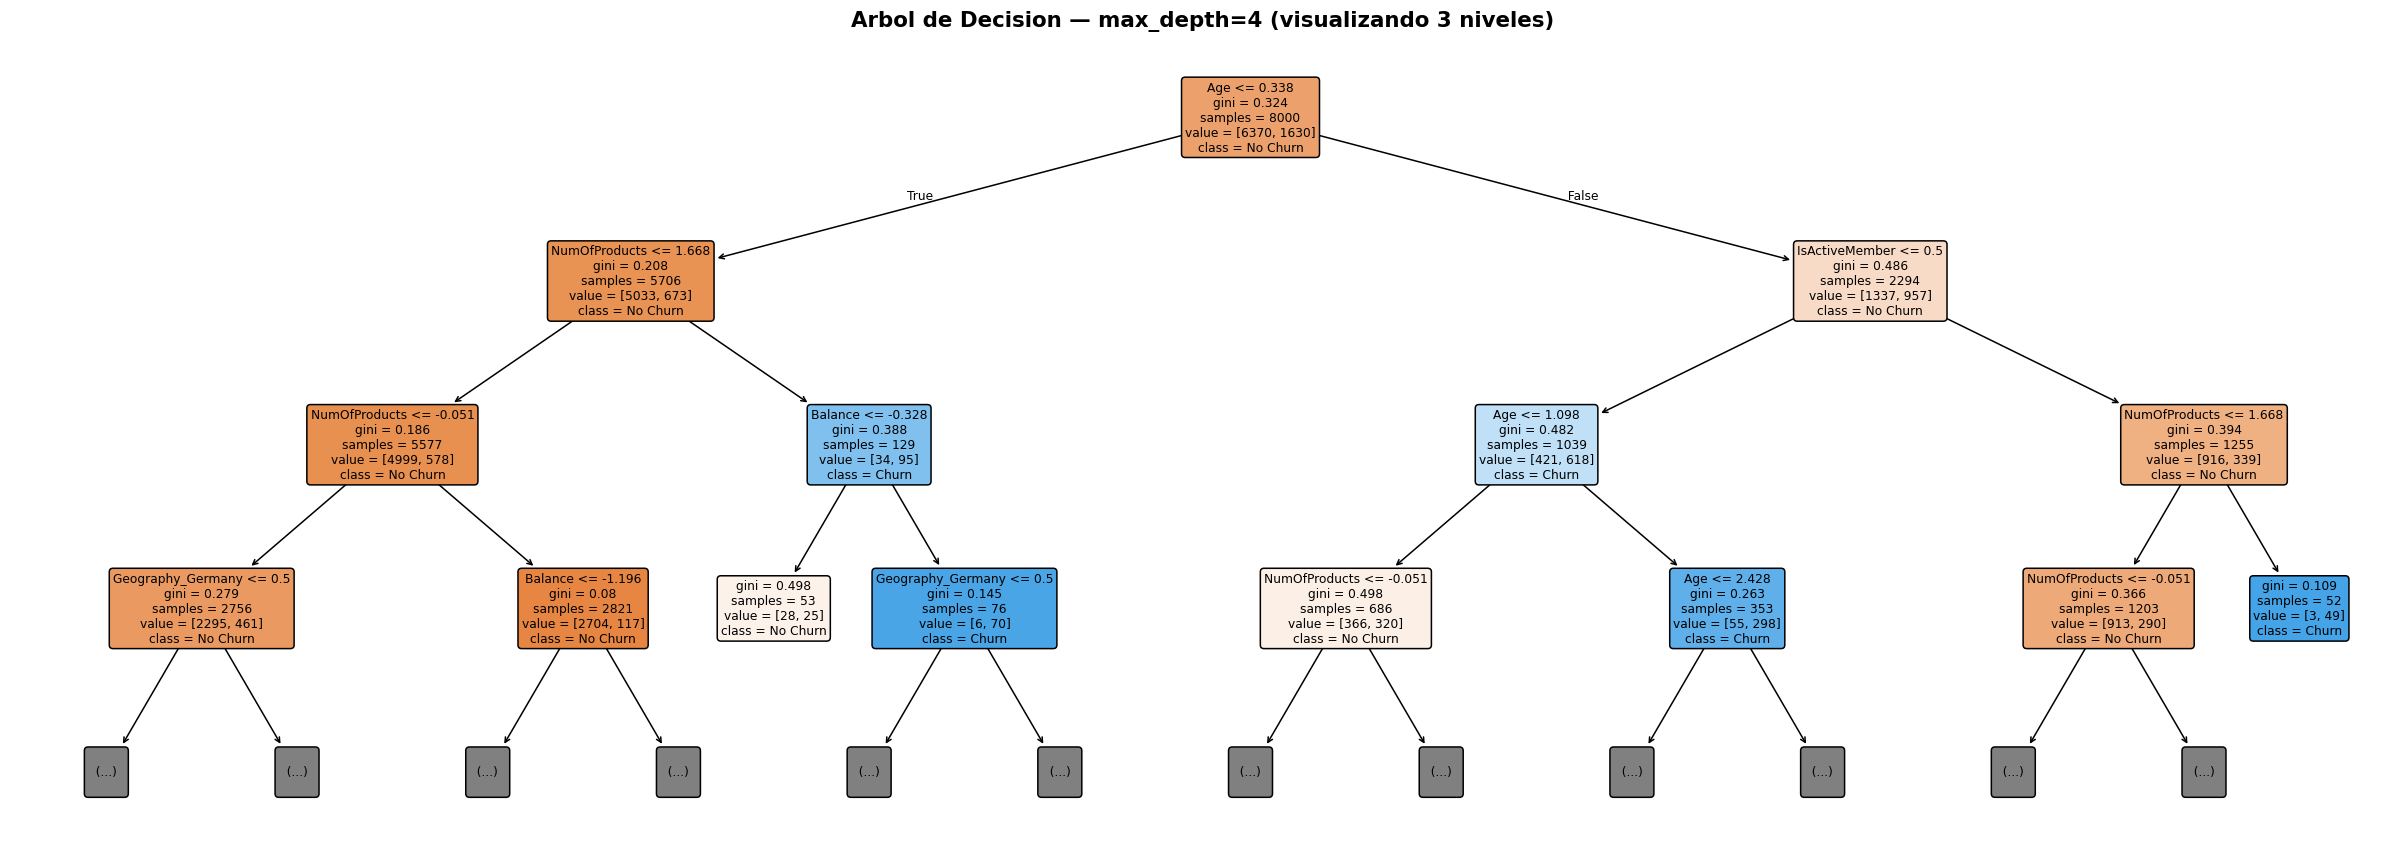

Primeras reglas del arbol:
|--- Age <= 0.34
|   |--- NumOfProducts <= 1.67
|   |   |--- NumOfProducts <= -0.05
|   |   |   |--- Geography_Germany <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Geography_Germany >  0.50
|   |   |   |   |--- class: 0
|   |   |--- NumOfProducts >  -0.05
|   |   |   |--- Balance <= -1.20
|   |   |   |   |--- class: 0
|   |   |   |--- Balance >  -1.20
|   |   |   |   |--- class: 0
|   |--- NumOfProducts >  1.67
|   |   |--- Balance <= -0.33
|   |   |   |--- class: 0
|   |   |--- Balance >  -0.33
|   |   |   |--- Geography_Germany <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- Geography_Germany >  0.50
|   |   |   |   |--- class: 1
|--- Age >  0.34
|   |--- IsActiveMember <= 0.50
|   |   |--- Age <= 1.10
|   |   |   |--- NumOfProducts <= -0.05
|   |   |   |   |--- class: 1
|   |   |   |--- NumOfProducts >  -0.05
|   |   |   |   |--- class: 0
|   |   |--- Age >  1.10
|   |   |   |--- Age <= 2.43
|   |   |   |   |--- class: 1
|   |   |   |--- A

In [30]:
# --- Arbol de Decision en Churn ---
dt_pipe = Pipeline(steps=[
    ('prep', preprocessor),
    ('clf',  DecisionTreeClassifier(max_depth=4, min_samples_leaf=30, random_state=42))
])
dt_pipe.fit(X_train, y_train)

y_pred_dt  = dt_pipe.predict(X_test)
y_proba_dt = dt_pipe.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)

print("ARBOL DE DECISION (max_depth=4) — Churn")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"  F1-Score : {f1_score(y_test, y_pred_dt):.4f}")
print(f"  AUC-ROC  : {auc(fpr_dt, tpr_dt):.4f}")

# Visualizar el arbol
dt_model_vis = dt_pipe.named_steps['clf']
ohe_feats_dt = dt_pipe.named_steps['prep'].named_transformers_['cat']['onehot'].get_feature_names_out(cat_cols).tolist()
feat_names_dt = num_cols + ohe_feats_dt + bin_cols

fig, ax = plt.subplots(figsize=(22, 8))
sktree.plot_tree(dt_model_vis, feature_names=feat_names_dt,
                 class_names=['No Churn', 'Churn'],
                 filled=True, rounded=True, fontsize=8, ax=ax, max_depth=3)
ax.set_title('Arbol de Decision — max_depth=4 (visualizando 3 niveles)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree.png', bbox_inches='tight')
plt.show()

# Reglas en texto (util para explicar al negocio)
rules = export_text(dt_model_vis, feature_names=feat_names_dt, max_depth=3)
print("Primeras reglas del arbol:")
print(rules[:1500])


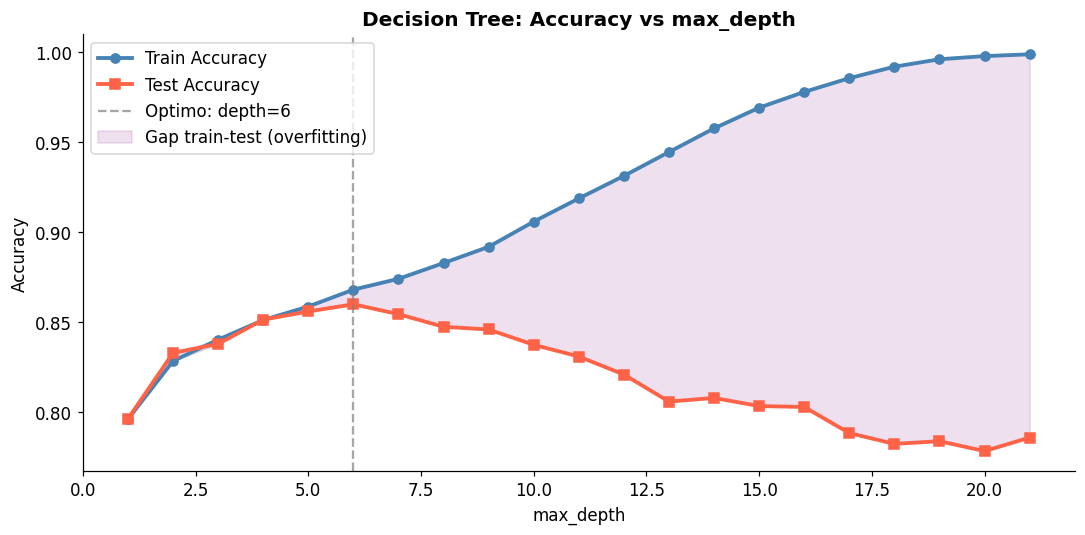

Mejor max_depth en test: 6
Train Accuracy con max_depth=20: 0.9978  (sobreajuste evidente)


In [31]:
# --- Curva de aprendizaje: efecto de max_depth ---
depths = range(1, 22)
train_scores_dt, test_scores_dt = [], []

for d in depths:
    pipe_d = Pipeline([('prep', preprocessor),
                       ('clf', DecisionTreeClassifier(max_depth=d, random_state=42))])
    pipe_d.fit(X_train, y_train)
    train_scores_dt.append(accuracy_score(y_train, pipe_d.predict(X_train)))
    test_scores_dt.append(accuracy_score(y_test,  pipe_d.predict(X_test)))

best_d = list(depths)[np.argmax(test_scores_dt)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_scores_dt, 'o-', color='steelblue', lw=2.5, label='Train Accuracy')
ax.plot(depths, test_scores_dt,  's-', color='tomato',    lw=2.5, label='Test Accuracy')
ax.axvline(best_d, color='gray', ls='--', alpha=0.7, label=f'Optimo: depth={best_d}')
ax.fill_between(depths,
                [min(tr, te) for tr, te in zip(train_scores_dt, test_scores_dt)],
                [max(tr, te) for tr, te in zip(train_scores_dt, test_scores_dt)],
                alpha=0.12, color='purple', label='Gap train-test (overfitting)')
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.set_title('Decision Tree: Accuracy vs max_depth', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('tree_depth.png', bbox_inches='tight')
plt.show()

print(f"Mejor max_depth en test: {best_d}")
print(f"Train Accuracy con max_depth=20: {train_scores_dt[-2]:.4f}  (sobreajuste evidente)")


---
## Modulo 7 — Metodos Ensemble: Random Forest y Gradient Boosting

### La idea central: la sabiduria de las masas

> Un conjunto de modelos **debiles e independientes** combinados produce
> un modelo fuerte y mas robusto que cualquier modelo individual.

### Las tres estrategias principales

| Estrategia | Mecanismo | Reduccion de... | Ejemplos |
|------------|-----------|-----------------|---------|
| **Bagging** | Bootstrap samples + promedio | Varianza | Random Forest |
| **Boosting** | Modelos secuenciales, cada uno corrige al anterior | Bias + varianza | AdaBoost, GBM, XGBoost |
| **Stacking** | Predicciones de base models como input de meta-modelo | Ambas | StackingClassifier |

---
### 7.1 Random Forest

Extiende el Bagging con **aleatoriedad adicional en los splits**:
- **B** arboles entrenados sobre bootstrap samples (muestra con reemplazo)
- En cada split, solo se considera un subconjunto de m ~ sqrt(p) features aleatorias
- Esto **decorrelaciona** los arboles -> la reduccion de varianza es mas efectiva

**Prediccion:** votacion mayoritaria (clasificacion) o promedio (regresion)

Ventaja sobre un arbol: por la ley de grandes numeros, los errores se promedian.

---
### 7.2 Gradient Boosting

Construye arboles **secuencialmente**. Cada nuevo arbol h_m ajusta los
**residuales** (gradiente negativo de la funcion de perdida) del ensemble anterior:

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

- **eta** = learning rate (0 < eta <= 1): controla la contribucion de cada arbol
- **subsample** < 1: Stochastic GBM, reduce varianza

**XGBoost** (Chen & Guestrin, 2016) agrega:
- Regularizacion L1/L2 en los pesos de las hojas
- Aproximacion de segundo orden del gradiente (metodo Newton)
- Procesamiento en paralelo por columnas


In [32]:
# --- 7.1 Random Forest ---
rf_pipe = Pipeline(steps=[
    ('prep', preprocessor),
    ('clf',  RandomForestClassifier(n_estimators=300, max_depth=8,
                                    min_samples_leaf=10, max_features='sqrt',
                                    n_jobs=-1, random_state=42))
])
rf_pipe.fit(X_train, y_train)

y_pred_rf  = rf_pipe.predict(X_test)
y_proba_rf = rf_pipe.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

print("RANDOM FOREST (300 arboles, max_depth=8) — Churn")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  F1-Score : {f1_score(y_test, y_pred_rf):.4f}")
print(f"  AUC-ROC  : {auc(fpr_rf, tpr_rf):.4f}")


RANDOM FOREST (300 arboles, max_depth=8) — Churn
  Accuracy : 0.8675
  F1-Score : 0.5719
  AUC-ROC  : 0.8650


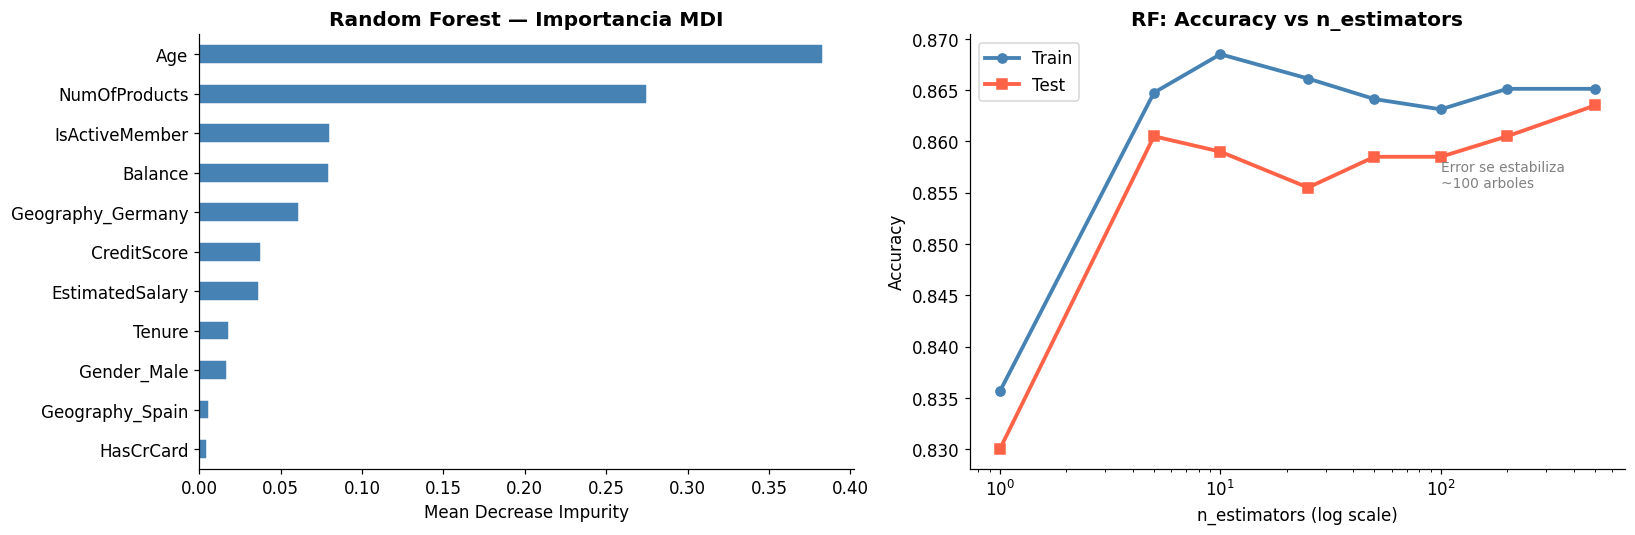

Top 5 features mas importantes:
Age                  0.382905
NumOfProducts        0.275173
IsActiveMember       0.080204
Balance              0.079515
Geography_Germany    0.061431


In [33]:
# --- Importancia de variables (MDI — Mean Decrease Impurity) ---
rf_model = rf_pipe.named_steps['clf']
ohe_feats_rf = rf_pipe.named_steps['prep'].named_transformers_['cat']['onehot'].get_feature_names_out(cat_cols).tolist()
feat_names_proc = num_cols + ohe_feats_rf + bin_cols

importances_rf = pd.Series(rf_model.feature_importances_, index=feat_names_proc)
importances_rf = importances_rf.sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

importances_rf.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Random Forest — Importancia MDI', fontweight='bold')
axes[0].set_xlabel('Mean Decrease Impurity')

# n_estimators vs Accuracy
n_trees_list = [1, 5, 10, 25, 50, 100, 200, 500]
rf_acc_train, rf_acc_test = [], []
for n in n_trees_list:
    pn = Pipeline([('prep', preprocessor),
                   ('clf', RandomForestClassifier(n_estimators=n, max_depth=6,
                                                   n_jobs=-1, random_state=42))])
    pn.fit(X_train, y_train)
    rf_acc_train.append(accuracy_score(y_train, pn.predict(X_train)))
    rf_acc_test.append( accuracy_score(y_test,  pn.predict(X_test)))

axes[1].semilogx(n_trees_list, rf_acc_train, 'o-', color='steelblue', lw=2.5, label='Train')
axes[1].semilogx(n_trees_list, rf_acc_test,  's-', color='tomato',    lw=2.5, label='Test')
axes[1].set_xlabel('n_estimators (log scale)'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('RF: Accuracy vs n_estimators', fontweight='bold')
axes[1].legend()
axes[1].annotate('Error se estabiliza\n~100 arboles', xy=(100, rf_acc_test[5]-0.003),
                  fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('rf_analysis.png', bbox_inches='tight')
plt.show()

print("Top 5 features mas importantes:")
print(importances_rf.tail(5).sort_values(ascending=False).to_string())


XGBOOST — Churn
  Accuracy : 0.8685
  F1-Score : 0.6021
  AUC-ROC  : 0.8597


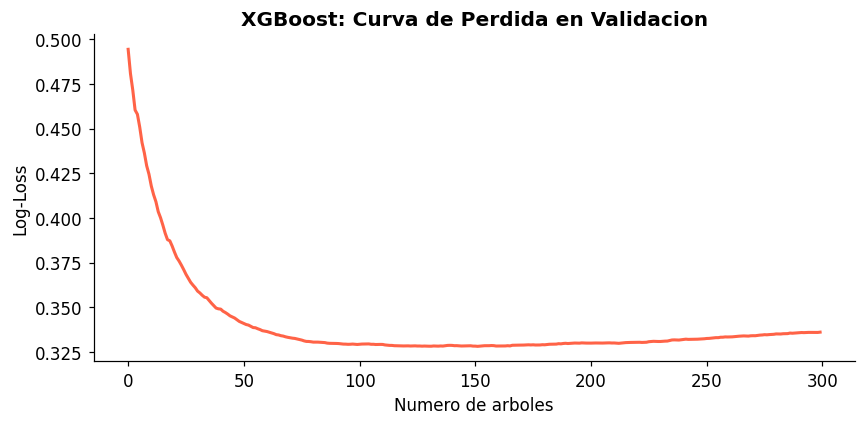

In [41]:
# --- XGBoost (si disponible) ---
if BOOSTING_AVAILABLE:
    Xtrain_p2 = preprocessor.fit_transform(X_train)
    Xtest_p2  = preprocessor.transform(X_test)

    xgb_model = xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0
    )
    xgb_model.fit(Xtrain_p2, y_train,
                  eval_set=[(Xtest_p2, y_test)], verbose=False)

    y_pred_xgb  = xgb_model.predict(Xtest_p2)
    y_proba_xgb = xgb_model.predict_proba(Xtest_p2)[:, 1]
    fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

    print("XGBOOST — Churn")
    print(f"  Accuracy : {accuracy_score(y_test, y_pred_xgb):.4f}")
    print(f"  F1-Score : {f1_score(y_test, y_pred_xgb):.4f}")
    print(f"  AUC-ROC  : {auc(fpr_xgb, tpr_xgb):.4f}")

    # Curva de perdida por iteracion
    results_xgb = xgb_model.evals_result()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(results_xgb['validation_0']['logloss'], color='tomato', lw=2)
    ax.set_xlabel('Numero de arboles'); ax.set_ylabel('Log-Loss')
    ax.set_title('XGBoost: Curva de Perdida en Validacion', fontweight='bold')
    plt.tight_layout()
    plt.savefig('xgb_curve.png', bbox_inches='tight')
    plt.show()
else:
    print("XGBoost no disponible. pip install xgboost")
    # Usar GB como proxy
    y_pred_xgb  = y_pred_gb
    y_proba_xgb = y_proba_gb
    fpr_xgb, tpr_xgb = fpr_gb, tpr_gb


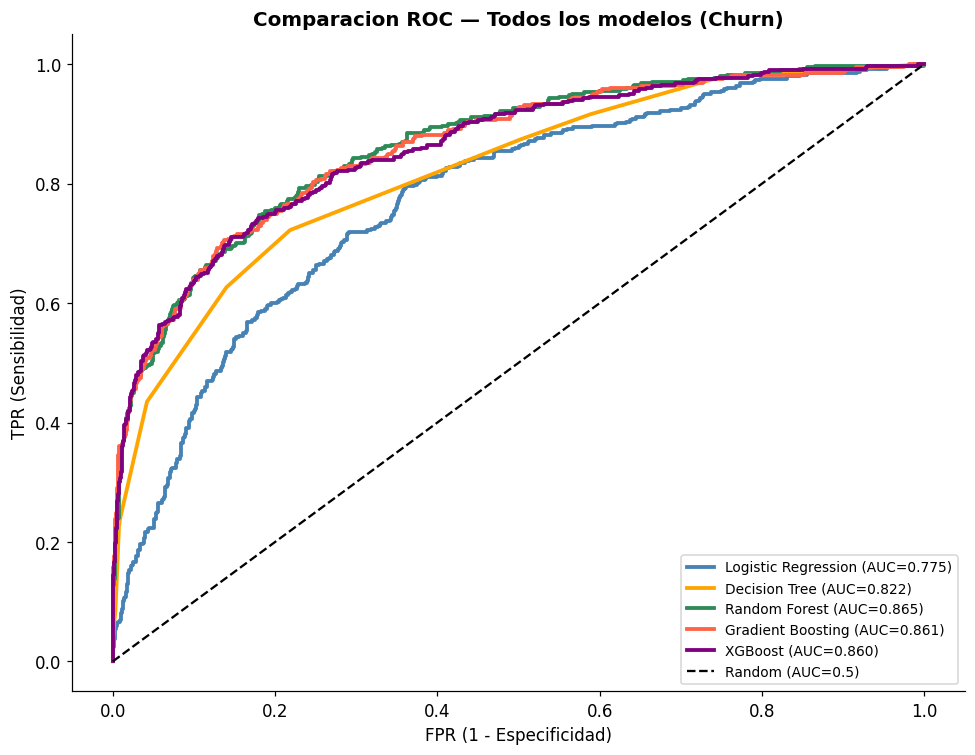

In [36]:
# --- Comparacion ROC de todos los modelos ---
fig, ax = plt.subplots(figsize=(9, 7))

models_roc = {
    'Logistic Regression': (fpr_lr, tpr_lr, 'steelblue'),
    'Decision Tree':       (fpr_dt, tpr_dt, 'orange'),
    'Random Forest':       (fpr_rf, tpr_rf, 'seagreen'),
    'Gradient Boosting':   (fpr_gb, tpr_gb, 'tomato'),
    'XGBoost':             (fpr_xgb, tpr_xgb, 'purple'),
}

for name, (fpr_, tpr_, col) in models_roc.items():
    roc_auc_ = auc(fpr_, tpr_)
    ax.plot(fpr_, tpr_, color=col, lw=2.5, label=f'{name} (AUC={roc_auc_:.3f})')

ax.plot([0,1],[0,1],'k--',lw=1.5, label='Random (AUC=0.5)')
ax.set_xlabel('FPR (1 - Especificidad)'); ax.set_ylabel('TPR (Sensibilidad)')
ax.set_title('Comparacion ROC — Todos los modelos (Churn)', fontweight='bold', fontsize=13)
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('roc_comparison.png', bbox_inches='tight')
plt.show()


---
## Modulo 8 — Evaluacion de Modelos y Cross-Validation

### La Matriz de Confusion

|  | Predicho 0 | Predicho 1 |
|--|-----------|-----------|
| **Real 0** | TN (True Negative) | FP (False Positive) |
| **Real 1** | FN (False Negative) | TP (True Positive) |

### Metricas derivadas

| Metrica | Formula | Intuicion | Cuando priorizarla |
|---------|---------|-----------|-------------------|
| **Accuracy** | (TP+TN)/total | Fraccion correcta total | Clases balanceadas |
| **Precision** | TP/(TP+FP) | De los que predigo positivos, cuantos lo son? | Minimizar FP (spam, publicidad) |
| **Recall (TPR)** | TP/(TP+FN) | De los positivos reales, cuantos detecto? | Minimizar FN (cancer, fraude, churn) |
| **F1-Score** | 2PR/(P+R) | Media armonica de Precision y Recall | Desbalanceo de clases |
| **AUC-ROC** | Area bajo ROC | Capacidad de ranking (umbral-independiente) | Comparacion de modelos |
| **PR-AUC** | Area bajo P-R | Mas informativo cuando hay pocos positivos | Datos muy desbalanceados |

### K-Fold Stratified Cross-Validation

```
Dataset: [fold1][fold2][fold3][fold4][fold5]
Iter 1:  TEST   TRAIN  TRAIN  TRAIN  TRAIN  -> score_1
Iter 2:  TRAIN  TEST   TRAIN  TRAIN  TRAIN  -> score_2
Iter 3:  TRAIN  TRAIN  TEST   TRAIN  TRAIN  -> score_3
Iter 4:  TRAIN  TRAIN  TRAIN  TEST   TRAIN  -> score_4
Iter 5:  TRAIN  TRAIN  TRAIN  TRAIN  TEST   -> score_5
```
**Resultado:** mean(scores) +/- std(scores)

Ventaja: usa todos los datos para entrenar Y para validar.
Mas confiable que un solo split train/test.


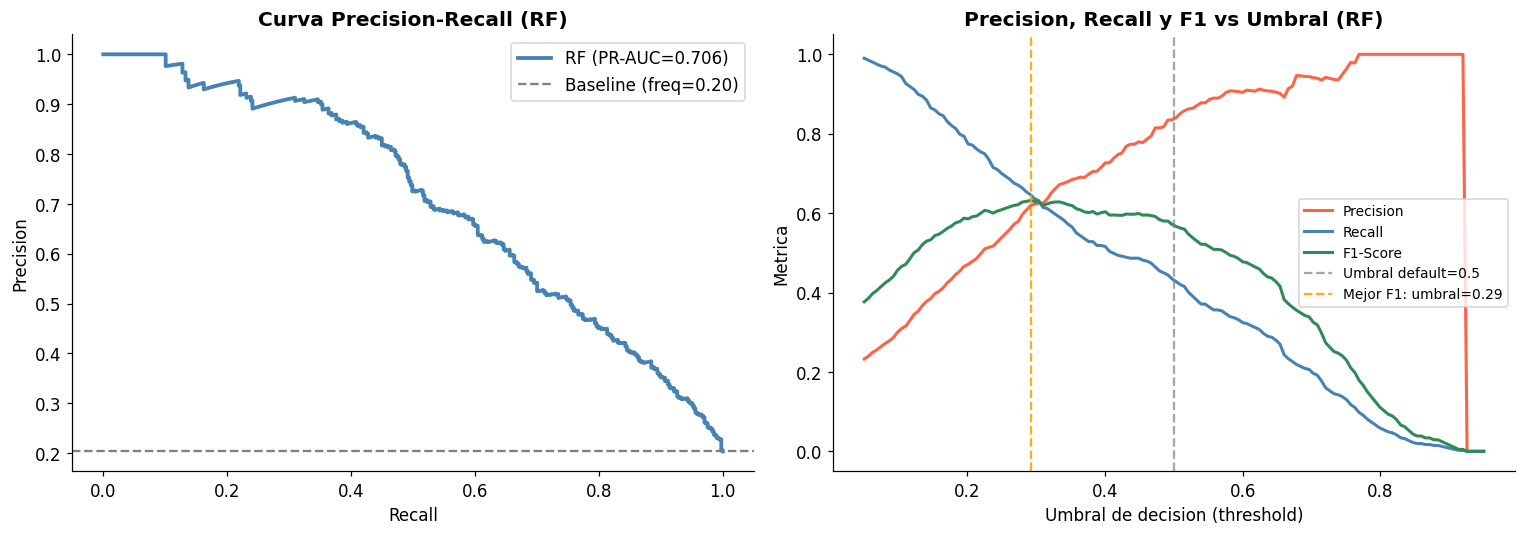

Umbral optimo para F1: 0.29 (no siempre es 0.5)
En churn bancario: bajar el umbral aumenta Recall (detectamos mas clientes en riesgo)
a costa de mas Falsos Positivos (llamadas de retencion innecesarias)


In [37]:
# --- Precision-Recall Curve y efecto del umbral de decision ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR Curve
prec_rf, rec_rf, thrs_pr = precision_recall_curve(y_test, y_proba_rf)
pr_auc_rf = auc(rec_rf, prec_rf)
axes[0].plot(rec_rf, prec_rf, color='steelblue', lw=2.5,
             label=f'RF (PR-AUC={pr_auc_rf:.3f})')
axes[0].axhline(y_test.mean(), color='gray', ls='--',
                label=f'Baseline (freq={y_test.mean():.2f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Curva Precision-Recall (RF)', fontweight='bold')
axes[0].legend()

# Efecto del umbral
thresholds_plot = np.linspace(0.05, 0.95, 150)
precs_t, recs_t, f1s_t = [], [], []
for t in thresholds_plot:
    y_t = (y_proba_rf >= t).astype(int)
    precs_t.append(precision_score(y_test, y_t, zero_division=0))
    recs_t.append(recall_score(y_test, y_t, zero_division=0))
    f1s_t.append(f1_score(y_test, y_t, zero_division=0))

best_f1_thr = thresholds_plot[np.argmax(f1s_t)]
axes[1].plot(thresholds_plot, precs_t, color='tomato',    lw=2, label='Precision')
axes[1].plot(thresholds_plot, recs_t,  color='steelblue', lw=2, label='Recall')
axes[1].plot(thresholds_plot, f1s_t,   color='seagreen',  lw=2, label='F1-Score')
axes[1].axvline(0.5, color='gray', ls='--', alpha=0.7, label='Umbral default=0.5')
axes[1].axvline(best_f1_thr, color='orange', ls='--', alpha=0.9,
                label=f'Mejor F1: umbral={best_f1_thr:.2f}')
axes[1].set_xlabel('Umbral de decision (threshold)'); axes[1].set_ylabel('Metrica')
axes[1].set_title('Precision, Recall y F1 vs Umbral (RF)', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('evaluation_metrics.png', bbox_inches='tight')
plt.show()

print(f"Umbral optimo para F1: {best_f1_thr:.2f} (no siempre es 0.5)")
print("En churn bancario: bajar el umbral aumenta Recall (detectamos mas clientes en riesgo)")
print("a costa de mas Falsos Positivos (llamadas de retencion innecesarias)")


In [38]:
# --- K-Fold Cross-Validation comparando todos los modelos ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Cross-Validation (StratifiedKFold, k=5):")
print("=" * 73)
print(f"  {'Modelo':<25} {'AUC mean':>9} {'AUC std':>9} {'F1 mean':>9} {'F1 std':>9}")
print("=" * 73)

for name, pipe in [
    ('Logistic Regression', log_pipe),
    ('Decision Tree',       dt_pipe),
    ('Random Forest',       rf_pipe),
    ('Gradient Boosting',   gb_pipe),
]:
    auc_cv = cross_val_score(pipe, X, y, cv=skf, scoring='roc_auc', n_jobs=-1)
    f1_cv  = cross_val_score(pipe, X, y, cv=skf, scoring='f1',      n_jobs=-1)
    print(f"  {name:<25} {auc_cv.mean():>9.4f} {auc_cv.std():>9.4f} "
          f"{f1_cv.mean():>9.4f} {f1_cv.std():>9.4f}")
print()
print("Importante: el std indica la estabilidad del modelo.")
print("Un modelo con media alta pero std alta es menos confiable en produccion.")


Cross-Validation (StratifiedKFold, k=5):
  Modelo                     AUC mean   AUC std   F1 mean    F1 std
  Logistic Regression          0.7662    0.0146    0.3121    0.0166
  Decision Tree                0.8190    0.0116    0.5029    0.0204
  Random Forest                0.8622    0.0070    0.5530    0.0225
  Gradient Boosting            0.8664    0.0051    0.5905    0.0251

Importante: el std indica la estabilidad del modelo.
Un modelo con media alta pero std alta es menos confiable en produccion.


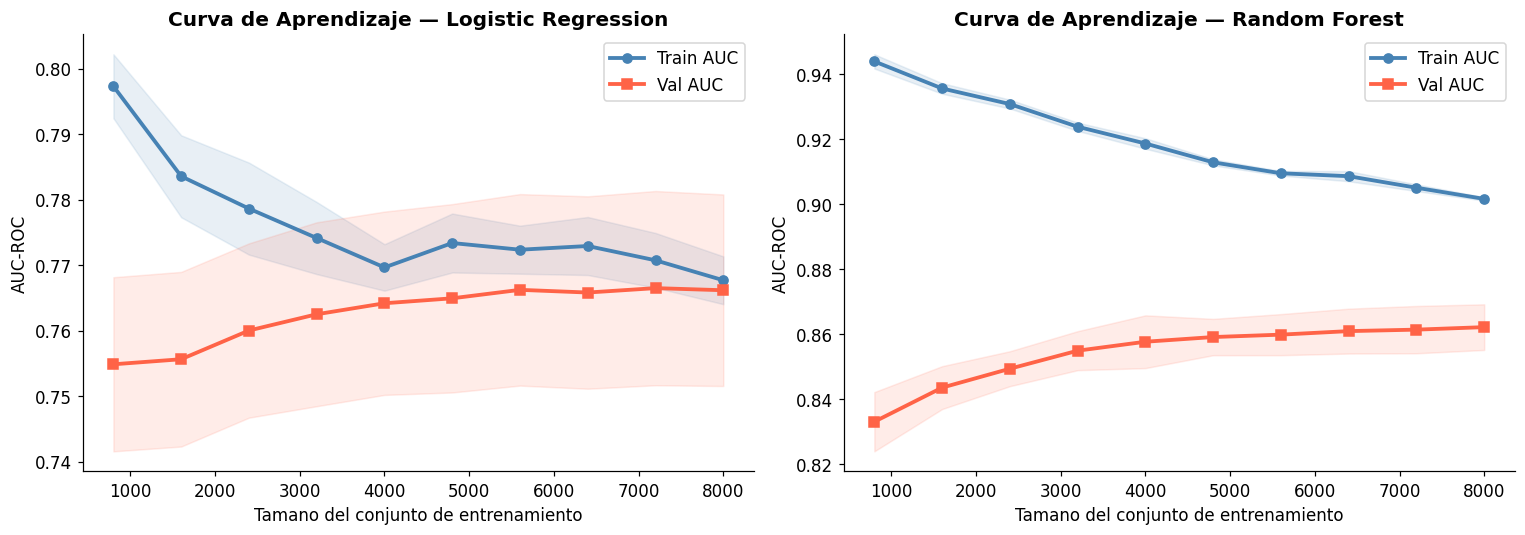

Como interpretar las Learning Curves:
  Gap grande (train >> val):    overfitting -> mas datos O regularizacion
  Ambas curvas bajas y planas:  underfitting -> modelo mas complejo O mas features
  Ambas curvas convergen arriba: buen balance, mas datos podria ayudar


In [39]:
# --- Learning Curves (diagnostico) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, pipe) in zip(axes, [
    ('Logistic Regression', log_pipe),
    ('Random Forest',       rf_pipe),
]):
    tr_sizes, tr_sc, va_sc = learning_curve(
        pipe, X, y,
        cv=StratifiedKFold(5, shuffle=True, random_state=42),
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='roc_auc', n_jobs=-1
    )
    tr_m, tr_s = tr_sc.mean(1), tr_sc.std(1)
    va_m, va_s = va_sc.mean(1), va_sc.std(1)

    ax.plot(tr_sizes, tr_m, 'o-', color='steelblue', lw=2.5, label='Train AUC')
    ax.plot(tr_sizes, va_m, 's-', color='tomato',    lw=2.5, label='Val AUC')
    ax.fill_between(tr_sizes, tr_m-tr_s, tr_m+tr_s, alpha=0.12, color='steelblue')
    ax.fill_between(tr_sizes, va_m-va_s, va_m+va_s, alpha=0.12, color='tomato')
    ax.set_xlabel('Tamano del conjunto de entrenamiento')
    ax.set_ylabel('AUC-ROC')
    ax.set_title(f'Curva de Aprendizaje — {name}', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('learning_curves.png', bbox_inches='tight')
plt.show()

print("Como interpretar las Learning Curves:")
print("  Gap grande (train >> val):    overfitting -> mas datos O regularizacion")
print("  Ambas curvas bajas y planas:  underfitting -> modelo mas complejo O mas features")
print("  Ambas curvas convergen arriba: buen balance, mas datos podria ayudar")


---
## Modulo 9 — Ajuste de Hiperparametros (Hyperparameter Optimization)

### Parametros vs Hiperparametros

| Tipo | Definicion | Ejemplos | Como se obtienen |
|------|------------|---------|-----------------|
| **Parametros** | Se aprenden del dato | theta, w, beta | Optimizacion (GD, OLS) |
| **Hiperparametros** | Se definen antes del entrenamiento | C, max_depth, n_estimators, alpha | Busqueda + CV |

### Estrategias de busqueda

| Metodo | Ventaja | Desventaja |
|--------|---------|------------|
| **Grid Search** | Exhaustivo, reproducible | Costoso: O(k^p) |
| **Random Search** | Eficiente, explora bien | No exhaustivo |
| **Bayesian (Optuna)** | Aprende del historial, muy eficiente | Implementacion mas compleja |
| **Halving/Successive Halving** | Muy rapido, presupuesto adaptativo | sklearn experimental |

**Regla:** el ajuste SIEMPRE sobre validacion (CV), **nunca mirar el test set**.

### Espacio de busqueda tipico para Random Forest

```python
params = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [3, 5, 8, 12, None],
    'min_samples_leaf': [5, 10, 20, 50],
    'max_features':     ['sqrt', 'log2', 0.5],
}
```


In [40]:
# --- RandomizedSearchCV para Random Forest ---
param_dist = {
    'clf__n_estimators':     randint(100, 600),
    'clf__max_depth':        randint(3, 15),
    'clf__min_samples_leaf': randint(5, 60),
    'clf__max_features':     ['sqrt', 'log2', 0.5],
    'clf__min_samples_split':randint(2, 20),
}

rf_pipe_hpo = Pipeline(steps=[
    ('prep', preprocessor),
    ('clf',  RandomForestClassifier(n_jobs=-1, random_state=42))
])

rs_cv = RandomizedSearchCV(
    rf_pipe_hpo, param_dist,
    n_iter=40,
    cv=StratifiedKFold(3, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1, random_state=42, verbose=0
)
rs_cv.fit(X_train, y_train)

print("RANDOM SEARCH RESULTS (40 iteraciones, 3-fold CV):")
print(f"  Mejor AUC (CV): {rs_cv.best_score_:.4f}")
print("  Mejores hiperparametros:")
for k, v in rs_cv.best_params_.items():
    print(f"    {k.replace('clf__',''):<25}: {v}")

best_rf_hpo  = rs_cv.best_estimator_
y_pred_hpo   = best_rf_hpo.predict(X_test)
y_proba_hpo  = best_rf_hpo.predict_proba(X_test)[:, 1]
print(f"\n  AUC en Test: {auc(*roc_curve(y_test, y_proba_hpo)[:2]):.4f}")
print(f"  F1  en Test: {f1_score(y_test, y_pred_hpo):.4f}")


RANDOM SEARCH RESULTS (40 iteraciones, 3-fold CV):
  Mejor AUC (CV): 0.8589
  Mejores hiperparametros:
    max_depth                : 7
    max_features             : 0.5
    min_samples_leaf         : 18
    min_samples_split        : 4
    n_estimators             : 356

  AUC en Test: 0.8639
  F1  en Test: 0.5888


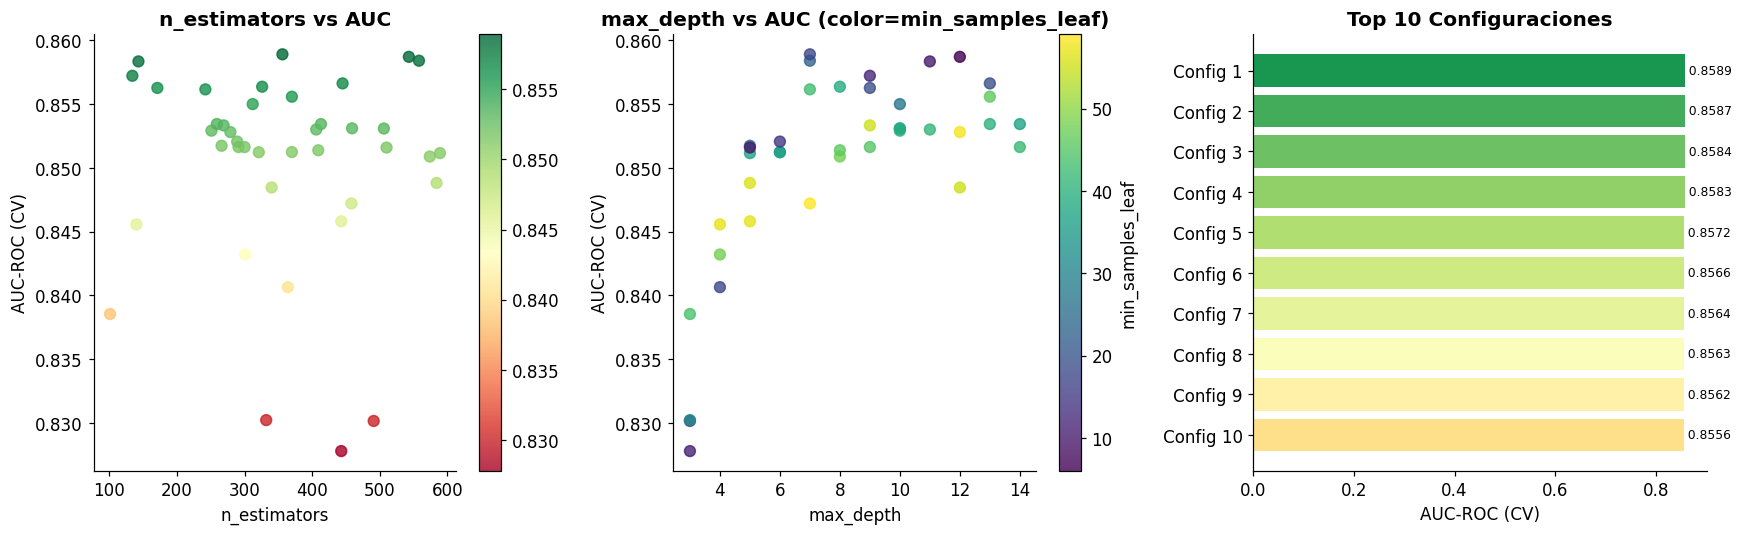

In [42]:
# --- Visualizacion del espacio de busqueda ---
results_hpo = pd.DataFrame(rs_cv.cv_results_)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# n_estimators vs AUC
sc0 = axes[0].scatter(results_hpo['param_clf__n_estimators'],
                       results_hpo['mean_test_score'],
                       c=results_hpo['mean_test_score'],
                       cmap='RdYlGn', s=50, alpha=0.8)
axes[0].set_xlabel('n_estimators'); axes[0].set_ylabel('AUC-ROC (CV)')
axes[0].set_title('n_estimators vs AUC', fontweight='bold')
plt.colorbar(sc0, ax=axes[0])

# max_depth vs AUC
sc1 = axes[1].scatter(results_hpo['param_clf__max_depth'],
                       results_hpo['mean_test_score'],
                       c=results_hpo['param_clf__min_samples_leaf'],
                       cmap='viridis', s=50, alpha=0.8)
axes[1].set_xlabel('max_depth'); axes[1].set_ylabel('AUC-ROC (CV)')
axes[1].set_title('max_depth vs AUC (color=min_samples_leaf)', fontweight='bold')
plt.colorbar(sc1, ax=axes[1], label='min_samples_leaf')

# Ranking de los mejores configs
top_k = results_hpo.nlargest(10, 'mean_test_score')
axes[2].barh(range(10), top_k['mean_test_score'].values[::-1],
             color=plt.cm.RdYlGn(np.linspace(0.4, 0.9, 10)))
axes[2].set_yticks(range(10))
axes[2].set_yticklabels([f'Config {i+1}' for i in range(10)][::-1])
axes[2].set_xlabel('AUC-ROC (CV)')
axes[2].set_title('Top 10 Configuraciones', fontweight='bold')
for i, v in enumerate(top_k['mean_test_score'].values[::-1]):
    axes[2].text(v, i, f' {v:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('hyperparam_search.png', bbox_inches='tight')
plt.show()


---
## Modulo 10 — Support Vector Machines (SVM)

### La idea central: hiperplano de maximo margen

Dado un dataset linealmente separable, existen infinitos hiperplanos que lo separan.
SVM busca el **hiperplano de maximo margen**:

$$\text{Margen} = \frac{2}{\|\mathbf{w}\|}$$

Maximizar el margen equivale a:
$$\min \frac{1}{2}\|w\|^2 \quad \text{s.t.} \quad y_i(w^T x_i + b) \geq 1, \; \forall i$$

### SVM suave (Soft-Margin) con slack variables xi_i >= 0:

$$\min \frac{1}{2}\|w\|^2 + C \sum_{i=1}^{n} \xi_i \quad \text{s.t.} \quad y_i(w^T x_i + b) \geq 1 - \xi_i$$

- **C grande** -> penaliza fuerte los errores, margen pequeno (sobreajuste)
- **C pequeno** -> margen amplio, tolera errores (regularizacion)

### El Kernel Trick

Para datos no linealmente separables, el kernel mapea a un espacio de mayor dimension
**sin computar explicitamente la transformacion** (kernel trick via el producto interno):

| Kernel | K(x,x') | Parametros |
|--------|---------|-----------|
| Lineal | x'x | ninguno |
| RBF | exp(-gamma * ||x-x'||^2) | gamma |
| Polinomial | (x'x + c)^d | c, d |

### Support Vectors
Los datos que quedan en el margen o lo violan son los **support vectors**.
Solo ellos determinan el hiperplano (los demas puntos son irrelevantes).


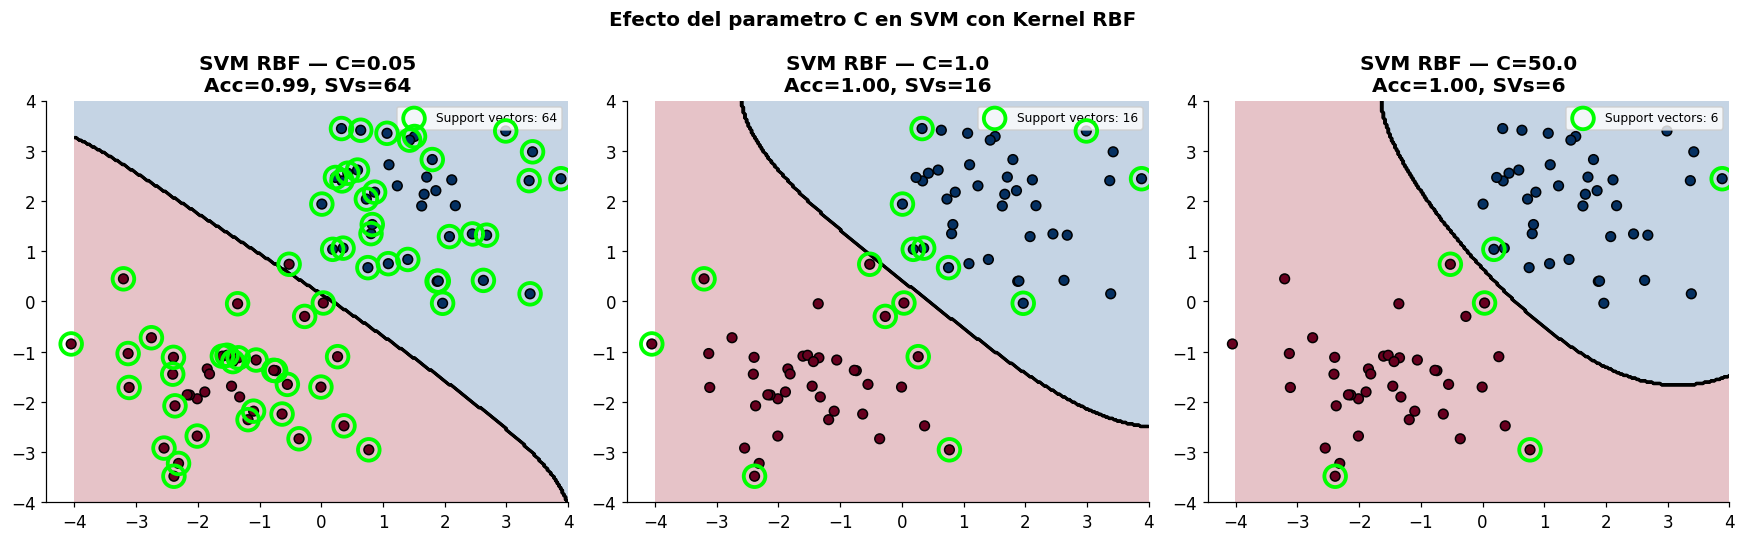

C pequeno: margen amplio, mas SVs, mas tolerante a errores (mas regularizacion)
C grande:  margen estrecho, menos SVs, ajusta mejor al train (riesgo de sobreajuste)


In [43]:
# --- Visualizacion del margen SVM en 2D ---
np.random.seed(0)
n_sv_demo = 80
X_sv = np.r_[np.random.randn(n_sv_demo//2, 2) - [1.5, 1.5],
             np.random.randn(n_sv_demo//2, 2) + [1.5, 1.5]]
y_sv = np.array([0]*(n_sv_demo//2) + [1]*(n_sv_demo//2))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
Cs_demo = [0.05, 1.0, 50.0]

for ax, C_val in zip(axes, Cs_demo):
    svm_demo = SVC(kernel='rbf', C=C_val, gamma='scale').fit(X_sv, y_sv)
    xx_sv, yy_sv = np.meshgrid(np.linspace(-4,4,300), np.linspace(-4,4,300))
    Z_sv = svm_demo.predict(np.c_[xx_sv.ravel(), yy_sv.ravel()]).reshape(xx_sv.shape)

    ax.contourf(xx_sv, yy_sv, Z_sv, alpha=0.25, cmap='RdBu')
    ax.contour(xx_sv, yy_sv, Z_sv, colors='k', linewidths=[1.5])
    ax.scatter(X_sv[:,0], X_sv[:,1], c=y_sv, cmap='RdBu', edgecolors='k', s=40, zorder=5)
    sv_pts = svm_demo.support_vectors_
    ax.scatter(sv_pts[:,0], sv_pts[:,1], s=200, facecolors='none',
               edgecolors='lime', linewidths=2.5, zorder=6,
               label=f'Support vectors: {len(sv_pts)}')
    acc_sv = accuracy_score(y_sv, svm_demo.predict(X_sv))
    ax.set_title(f'SVM RBF — C={C_val}\nAcc={acc_sv:.2f}, SVs={len(sv_pts)}', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Efecto del parametro C en SVM con Kernel RBF',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('svm_margin.png', bbox_inches='tight')
plt.show()

print("C pequeno: margen amplio, mas SVs, mas tolerante a errores (mas regularizacion)")
print("C grande:  margen estrecho, menos SVs, ajusta mejor al train (riesgo de sobreajuste)")


In [44]:
# --- SVM en Churn (subset para velocidad) ---
# SVM tiene complejidad O(n^2) a O(n^3) — no escala bien con n grande
# Para n > 50k: usar LinearSVC o SGDClassifier

np.random.seed(42)
idx_svm = np.random.choice(len(X_train), size=3000, replace=False)
svm_pipe = Pipeline(steps=[
    ('prep', preprocessor),
    ('clf',  SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42))
])
svm_pipe.fit(X_train.iloc[idx_svm], y_train.iloc[idx_svm])
y_pred_svm  = svm_pipe.predict(X_test)
y_proba_svm = svm_pipe.predict_proba(X_test)[:, 1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)

print("SVM (RBF, C=10) — Churn (subset n=3,000 para velocidad)")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"  F1-Score : {f1_score(y_test, y_pred_svm):.4f}")
print(f"  AUC-ROC  : {auc(fpr_svm, tpr_svm):.4f}")
print()
print("Nota sobre escalabilidad de SVM:")
print("  n < 10k:   SVC con kernel — ideal")
print("  n ~ 50k:   LinearSVC o SGDClassifier")
print("  n > 100k:  Random Forest o XGBoost")


SVM (RBF, C=10) — Churn (subset n=3,000 para velocidad)
  Accuracy : 0.8590
  F1-Score : 0.5580
  AUC-ROC  : 0.8212

Nota sobre escalabilidad de SVM:
  n < 10k:   SVC con kernel — ideal
  n ~ 50k:   LinearSVC o SGDClassifier
  n > 100k:  Random Forest o XGBoost


---
## Modulo 11 — Aprendizaje No Supervisado: PCA y K-Means

### PCA — Principal Component Analysis

**Objetivo:** encontrar las direcciones de maxima varianza en los datos.

**Algoritmo:**
1. Centrar los datos: X_tilde = X - mean(X)
2. Calcular la matriz de covarianza: Sigma = X_tilde' * X_tilde / (n-1)
3. Eigendescomposicion: Sigma = V * Lambda * V'
4. Los k eigenvectores con mayores eigenvalores son los k Componentes Principales

**Cada PC es una combinacion lineal** de las features originales.
PC1 maximiza la varianza proyectada, PC2 la segunda mayor, etc. (ortogonales entre si).

**Usos:** visualizacion, reduccion de dimension, decorrelacion para LR/SVM

---
### K-Means Clustering

**Objetivo:** particionar n puntos en k grupos minimizando la suma de distancias al centroide.

**Funcion objetivo (Within-Cluster Sum of Squares, WCSS):**
$$J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$

**Algoritmo de Lloyd (iterativo):**
1. Inicializar k centroides (K-Means++ para mejor inicializacion)
2. Asignar cada punto al centroide mas cercano (distancia euclidiana)
3. Recalcular centroides como la media de los puntos asignados
4. Repetir hasta convergencia (o max_iter)

**Como elegir k:**
- **Metodo del codo:** buscar el punto de inflexion en la curva WCSS vs k
- **Indice de Silueta:** mide que tan bien separados estan los clusters (rango [-1, 1])


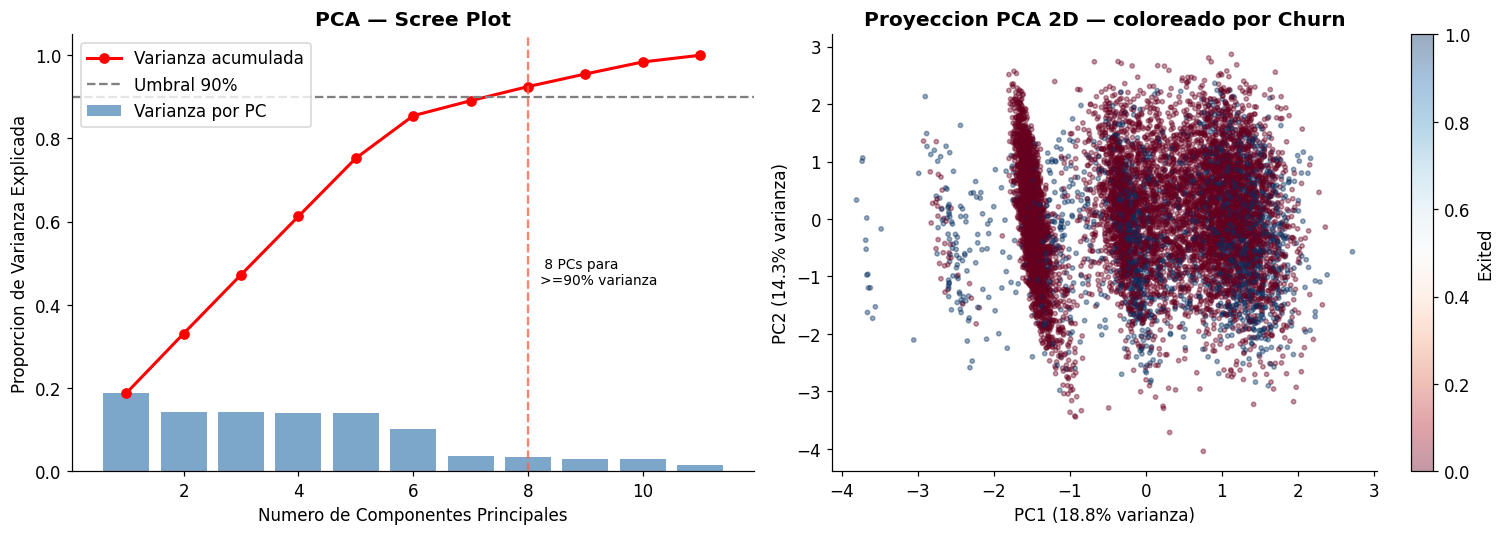

Se necesitan 8 componentes para explicar el 90% de la varianza
PC1 explica 18.8% | PC2 explica 14.3%

Loadings (contribucion de cada feature a PC1 y PC2):
                     PC1    PC2
CreditScore       -0.013  0.088
Age                0.134 -0.521
Tenure            -0.059  0.581
Balance            0.711  0.111
NumOfProducts     -0.677 -0.039
EstimatedSalary   -0.004  0.606
Geography_Germany  0.116  0.015
Geography_Spain   -0.045 -0.009
Gender_Male        0.008  0.012
HasCrCard         -0.006  0.006
IsActiveMember    -0.001 -0.044


In [45]:
# --- PCA en Churn ---
X_proc_pca = preprocessor.fit_transform(X)

pca_full = PCA().fit(X_proc_pca)
explained_var  = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)
n_90 = np.argmax(cumulative_var >= 0.9) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(explained_var)+1), explained_var, alpha=0.7,
            color='steelblue', label='Varianza por PC')
axes[0].plot(range(1, len(explained_var)+1), cumulative_var, 'ro-', lw=2,
             label='Varianza acumulada')
axes[0].axhline(0.90, color='gray', ls='--', label='Umbral 90%')
axes[0].axvline(n_90, color='tomato', ls='--', alpha=0.8)
axes[0].text(n_90+0.2, 0.45, f' {n_90} PCs para\n>=90% varianza', fontsize=9)
axes[0].set_xlabel('Numero de Componentes Principales')
axes[0].set_ylabel('Proporcion de Varianza Explicada')
axes[0].set_title('PCA — Scree Plot', fontweight='bold')
axes[0].legend()

# Proyeccion 2D
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_proc_pca)
sc_pca = axes[1].scatter(X_pca_2d[:,0], X_pca_2d[:,1],
                          c=y, alpha=0.4, cmap='RdBu', s=8)
axes[1].set_xlabel(f'PC1 ({explained_var[0]*100:.1f}% varianza)')
axes[1].set_ylabel(f'PC2 ({explained_var[1]*100:.1f}% varianza)')
axes[1].set_title('Proyeccion PCA 2D — coloreado por Churn', fontweight='bold')
plt.colorbar(sc_pca, ax=axes[1], label='Exited')

plt.tight_layout()
plt.savefig('pca_analysis.png', bbox_inches='tight')
plt.show()

print(f"Se necesitan {n_90} componentes para explicar el 90% de la varianza")
print(f"PC1 explica {explained_var[0]*100:.1f}% | PC2 explica {explained_var[1]*100:.1f}%")
print()
print("Loadings (contribucion de cada feature a PC1 y PC2):")
ohe_feats_pca = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(cat_cols).tolist()
feat_names_pca = num_cols + ohe_feats_pca + bin_cols
pc_loadings = pd.DataFrame(pca_2d.components_.T, index=feat_names_pca,
                            columns=['PC1', 'PC2'])
print(pc_loadings.round(3).to_string())


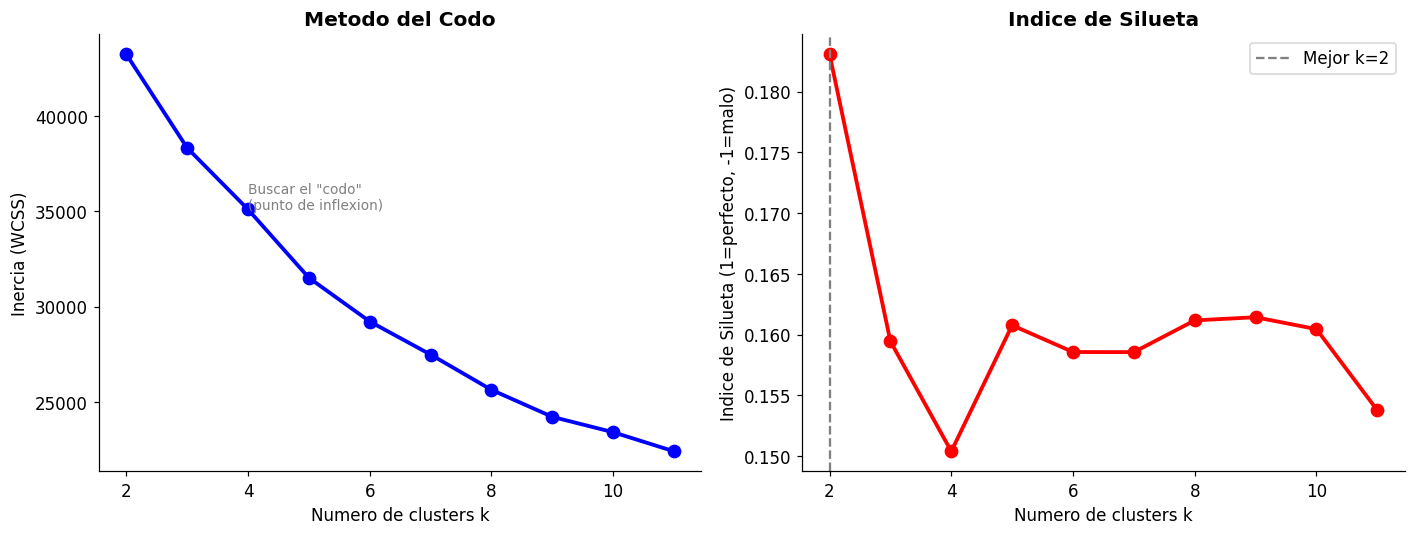

Mejor k segun Silhouette: 2


In [46]:
# --- K-Means: Elbow Method y Silhouette Score ---
X_pca_5d = PCA(n_components=5).fit_transform(X_proc_pca)

inertias_km, silhouettes_km = [], []
k_range_km = range(2, 12)

for k in k_range_km:
    km = KMeans(n_clusters=k, n_init='auto', random_state=42)
    labels_km = km.fit_predict(X_pca_5d)
    inertias_km.append(km.inertia_)
    silhouettes_km.append(silhouette_score(X_pca_5d, labels_km, sample_size=3000))

best_k_km = list(k_range_km)[np.argmax(silhouettes_km)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(k_range_km, inertias_km, 'bo-', lw=2.5, markersize=8)
axes[0].set_xlabel('Numero de clusters k')
axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_title('Metodo del Codo', fontweight='bold')
axes[0].annotate('Buscar el "codo"\n(punto de inflexion)',
                  xy=(4, inertias_km[2]), fontsize=9, color='gray')

axes[1].plot(k_range_km, silhouettes_km, 'ro-', lw=2.5, markersize=8)
axes[1].axvline(best_k_km, color='gray', ls='--', label=f'Mejor k={best_k_km}')
axes[1].set_xlabel('Numero de clusters k')
axes[1].set_ylabel('Indice de Silueta (1=perfecto, -1=malo)')
axes[1].set_title('Indice de Silueta', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('kmeans_selection.png', bbox_inches='tight')
plt.show()

print(f"Mejor k segun Silhouette: {best_k_km}")


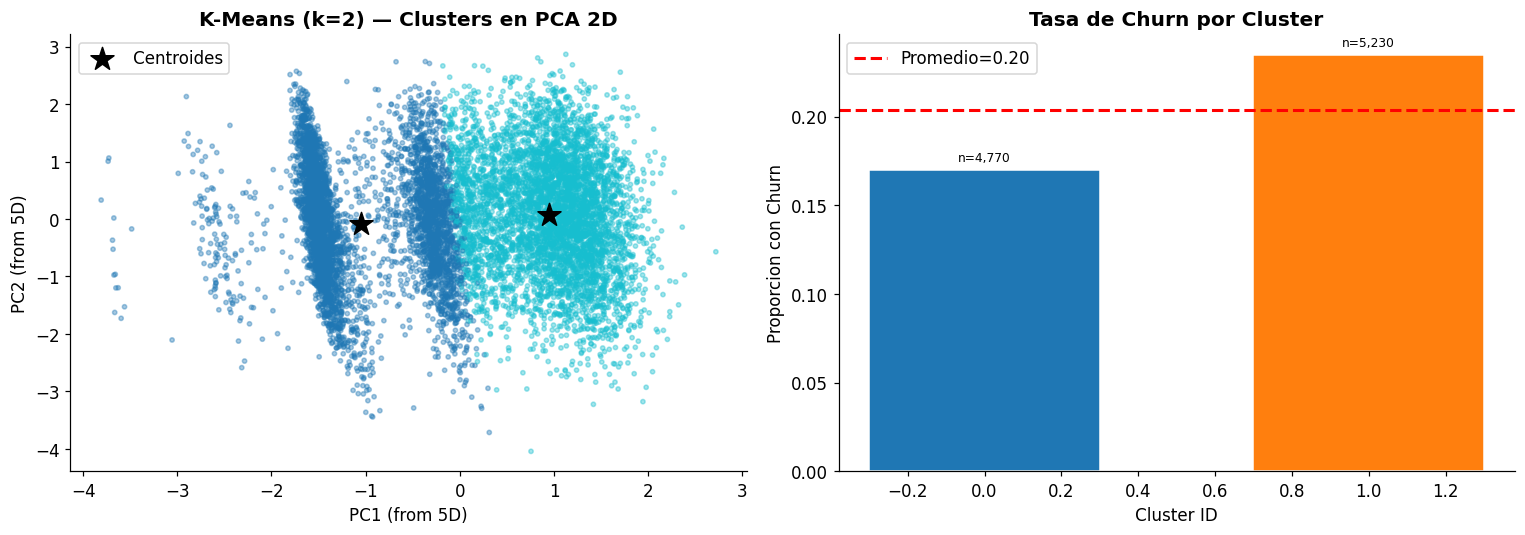

Perfil de cada cluster:
         Churn    Age    Balance
Cluster                         
0         0.17  38.33   23954.33
1         0.23  39.46  124397.08


In [48]:
# --- K-Means: visualizacion y perfil de churn por cluster ---
km_final = KMeans(n_clusters=best_k_km, n_init='auto', random_state=42)
cluster_labels = km_final.fit_predict(X_pca_5d)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clusters en espacio PCA 2D
sc_km = axes[0].scatter(X_pca_2d[:,0], X_pca_2d[:,1],
                         c=cluster_labels, alpha=0.4, cmap='tab10', s=8)

# FIXED: Project cluster centers from 5D to 2D space
# The cluster centers are in 5D PCA space, so we need to project them to 2D
pca_5d_to_2d = PCA(n_components=2)
X_pca_2d_from_5d = pca_5d_to_2d.fit_transform(X_pca_5d)
centers_2d = pca_5d_to_2d.transform(km_final.cluster_centers_)

axes[0].scatter(centers_2d[:,0], centers_2d[:,1],
                c='black', s=250, marker='*', zorder=10, label='Centroides')
axes[0].set_title(f'K-Means (k={best_k_km}) — Clusters en PCA 2D', fontweight='bold')
axes[0].set_xlabel('PC1 (from 5D)'); axes[0].set_ylabel('PC2 (from 5D)'); axes[0].legend()

# Tasa de churn por cluster
cluster_df = pd.DataFrame({'Cluster': cluster_labels, 'Churn': y.values,
                            'Age': X['Age'].values, 'Balance': X['Balance'].values})
churn_by_cluster = cluster_df.groupby('Cluster')['Churn'].mean()
size_by_cluster  = cluster_df.groupby('Cluster').size()

colors_km = sns.color_palette('tab10', best_k_km)
bars_km = axes[1].bar(churn_by_cluster.index, churn_by_cluster.values,
                       color=colors_km, edgecolor='white', width=0.6)
axes[1].axhline(y.mean(), color='red', ls='--', lw=2, label=f'Promedio={y.mean():.2f}')
for bar, sz in zip(bars_km, size_by_cluster.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'n={sz:,}', ha='center', fontsize=8)
axes[1].set_title('Tasa de Churn por Cluster', fontweight='bold')
axes[1].set_xlabel('Cluster ID'); axes[1].set_ylabel('Proporcion con Churn')
axes[1].legend()

plt.tight_layout()
plt.savefig('kmeans_profile.png', bbox_inches='tight')
plt.show()

print("Perfil de cada cluster:")
print(cluster_df.groupby('Cluster')[['Churn','Age','Balance']].mean().round(2).to_string())

---
## Modulo 12 — NLP Basico: Clasificacion de Texto

### Pipeline de NLP clasico

```
Texto crudo -> Limpieza -> Tokenizacion -> Vectorizacion -> Modelo -> Prediccion
```

### Representaciones de texto

**Bag of Words (BoW):**
Cada documento = vector de conteo de palabras. Ignora el orden.
Vocabulario de 10,000 palabras -> vector de 10,000 dimensiones (la mayoria 0).

**TF-IDF (Term Frequency - Inverse Document Frequency):**

$$\text{TF-IDF}(t, d) = \underbrace{\frac{\text{count}(t,d)}{|d|}}_{\text{TF}} \times \underbrace{\log\frac{N}{\text{df}(t)}}_{\text{IDF}}$$

- **TF:** frecuencia del termino en el documento (relevancia local)
- **IDF:** penaliza palabras muy frecuentes en todos los docs (stop words)
- Palabras raras que aparecen en pocos docs reciben mayor peso

**N-gramas:** capturar contexto local
- Unigrama: "machine", "learning" (tokens individuales)
- Bigrama: "machine learning" (pares de tokens)

### Naive Bayes Multinomial

Aplica el teorema de Bayes asumiendo independencia condicional entre features:

$$P(y \mid x_1, \ldots, x_n) \propto P(y) \prod_{i=1}^{n} P(x_i \mid y)$$

Muy efectivo para texto a pesar de la fuerte asuncion de independencia.
Rapido, robusto a datos escasos, excelente baseline para NLP.


In [49]:
# --- Carga y analisis de tweets ---
tweets = pd.read_csv('./Data/tweets.csv')
tweets = tweets.dropna(subset=['Tweet', 'Avg'])
tweets['sentiment'] = (tweets['Avg'] >= 0.6).astype(int)

print(f"Dimensiones tweets: {tweets.shape}")
print(f"Rango Avg: [{tweets['Avg'].min():.1f}, {tweets['Avg'].max():.1f}]")
print(f"Sentimiento positivo (Avg >= 0.6): {tweets['sentiment'].sum():,} ({tweets['sentiment'].mean()*100:.1f}%)")
print(f"Sentimiento negativo (Avg < 0.6):  {(tweets['sentiment']==0).sum():,}")
print()
tweets[['Tweet', 'Avg', 'sentiment']].head(5)


Dimensiones tweets: (1181, 3)
Rango Avg: [-2.0, 2.0]
Sentimiento positivo (Avg >= 0.6): 138 (11.7%)
Sentimiento negativo (Avg < 0.6):  1,043



,Tweet,Avg,sentiment
0,"I have to say, Apple has by far the best custo...",2.0,1
1,iOS 7 is so fricking smooth & beautiful!! #Tha...,2.0,1
2,LOVE U @APPLE,1.8,1
3,"Thank you @apple, loving my new iPhone 5S!!!!!...",1.8,1
4,.@apple has the best customer service. In and ...,1.8,1


In [50]:
# --- Limpieza de texto ---
def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r'@\w+', ' ', text)        # remover menciones
    text = re.sub(r'http\S+', ' ', text)      # remover URLs
    text = re.sub(r'#\w+', ' ', text)         # remover hashtags
    text = re.sub(r'[^a-z\s]', ' ', text)    # solo letras y espacios
    text = re.sub(r'\s+', ' ', text).strip()  # espacios multiples
    return text

tweets['text_clean'] = tweets['Tweet'].apply(clean_tweet)

print("Ejemplos de limpieza:")
print("=" * 70)
for i in range(4):
    orig = tweets['Tweet'].iloc[i]
    clean = tweets['text_clean'].iloc[i]
    print(f"ORIGINAL: {orig[:65]}")
    print(f"LIMPIO  : {clean[:65]}")
    print()


Ejemplos de limpieza:
ORIGINAL: I have to say, Apple has by far the best customer care service I 
LIMPIO  : i have to say apple has by far the best customer care service i h

ORIGINAL: iOS 7 is so fricking smooth & beautiful!! #ThanxApple @Apple
LIMPIO  : ios is so fricking smooth beautiful

ORIGINAL: LOVE U @APPLE
LIMPIO  : love u

ORIGINAL: Thank you @apple, loving my new iPhone 5S!!!!!  #apple #iphone5S 
LIMPIO  : thank you loving my new iphone s pic twitter com xmhjcu pcb



In [51]:
# --- Pipeline NLP: comparacion de vectorizadores y clasificadores ---
X_tw = tweets['text_clean']
y_tw = tweets['sentiment']

X_tw_tr, X_tw_te, y_tw_tr, y_tw_te = train_test_split(
    X_tw, y_tw, test_size=0.2, random_state=42, stratify=y_tw)

print(f"Train: {len(X_tw_tr)} tweets | Test: {len(X_tw_te)} tweets")

vectorizers_nlp = {
    'BoW (uni)':       CountVectorizer(max_features=2000, stop_words='english'),
    'BoW (1-2 gram)':  CountVectorizer(max_features=2000, ngram_range=(1,2), stop_words='english'),
    'TF-IDF (1-2g)':   TfidfVectorizer(max_features=2000, ngram_range=(1,2),
                                        stop_words='english', sublinear_tf=True),
}
classifiers_nlp = {
    'Naive Bayes':   MultinomialNB(alpha=0.5),
    'Logistic Reg.': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
}

print("=" * 63)
print(f"  {'Vectorizer':<20}  {'Clasificador':<15}  {'F1':>6}  {'AUC':>7}")
print("=" * 63)
for vec_name, vec in vectorizers_nlp.items():
    Xtr_v = vec.fit_transform(X_tw_tr)
    Xte_v = vec.transform(X_tw_te)
    for clf_name, clf_nlp in classifiers_nlp.items():
        clf_nlp.fit(Xtr_v, y_tw_tr)
        yp_ = clf_nlp.predict(Xte_v)
        ypr_= clf_nlp.predict_proba(Xte_v)[:, 1]
        f1_nlp  = f1_score(y_tw_te, yp_)
        auc_nlp = auc(*roc_curve(y_tw_te, ypr_)[:2])
        print(f"  {vec_name:<20}  {clf_name:<15}  {f1_nlp:>6.4f}  {auc_nlp:>7.4f}")


Train: 944 tweets | Test: 237 tweets
  Vectorizer            Clasificador         F1      AUC
  BoW (uni)             Naive Bayes      0.0541   0.6442
  BoW (uni)             Logistic Reg.    0.1212   0.6639
  BoW (1-2 gram)        Naive Bayes      0.0588   0.6425
  BoW (1-2 gram)        Logistic Reg.    0.0625   0.6415
  TF-IDF (1-2g)         Naive Bayes      0.0000   0.6283
  TF-IDF (1-2g)         Logistic Reg.    0.0000   0.6951


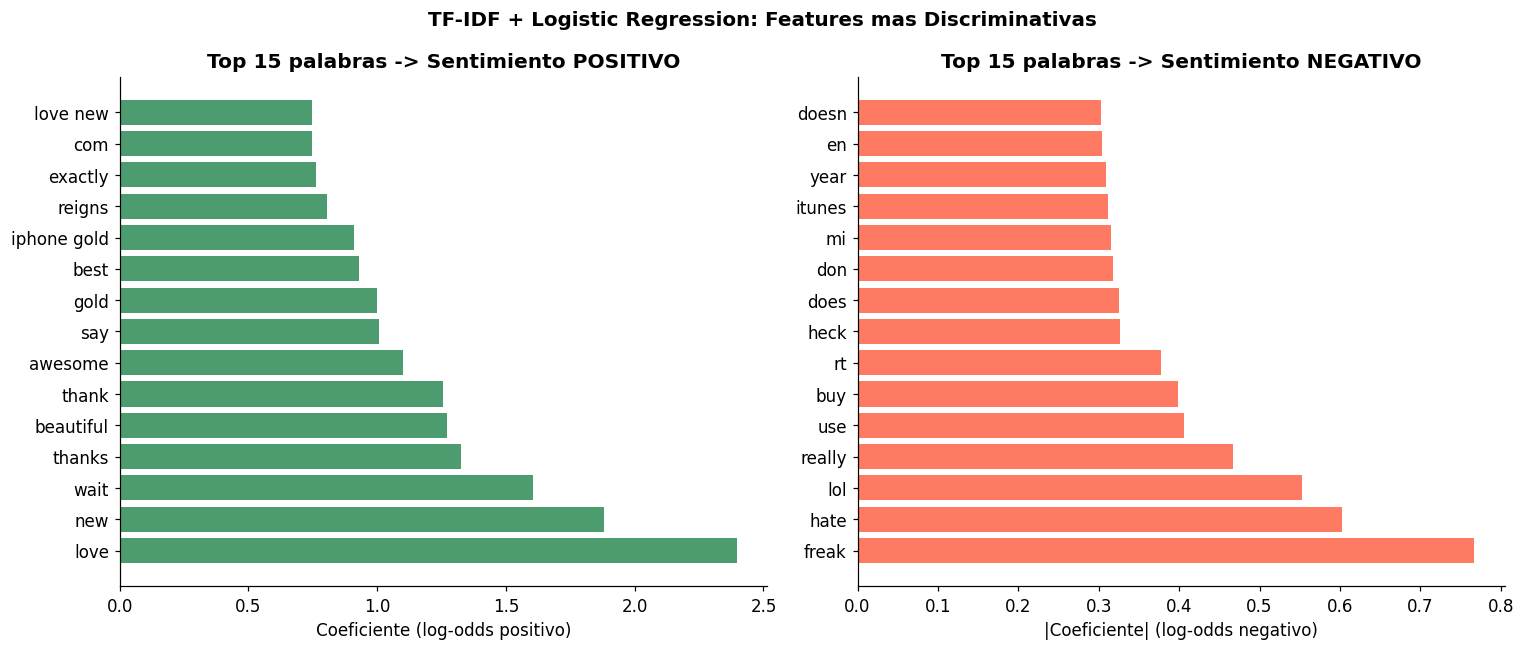

Evaluacion final — TF-IDF + LR:
              precision    recall  f1-score   support

    Negativo       0.88      1.00      0.94       209
    Positivo       0.00      0.00      0.00        28

    accuracy                           0.88       237
   macro avg       0.44      0.50      0.47       237
weighted avg       0.78      0.88      0.83       237



In [52]:
# --- Palabras mas discriminativas (TF-IDF + Logistic Regression) ---
vec_best = TfidfVectorizer(max_features=3000, ngram_range=(1,2),
                            stop_words='english', sublinear_tf=True)
clf_best = LogisticRegression(max_iter=1000, C=1.0, random_state=42)

Xtr_best = vec_best.fit_transform(X_tw_tr)
Xte_best = vec_best.transform(X_tw_te)
clf_best.fit(Xtr_best, y_tw_tr)

coef_nlp = clf_best.coef_[0]
vocab_nlp = np.array(vec_best.get_feature_names_out())

top_pos_idx = np.argsort(coef_nlp)[-15:][::-1]
top_neg_idx = np.argsort(coef_nlp)[:15]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(range(15), coef_nlp[top_pos_idx], color='seagreen', alpha=0.85)
axes[0].set_yticks(range(15)); axes[0].set_yticklabels(vocab_nlp[top_pos_idx])
axes[0].set_title('Top 15 palabras -> Sentimiento POSITIVO', fontweight='bold')
axes[0].set_xlabel('Coeficiente (log-odds positivo)')

axes[1].barh(range(15), np.abs(coef_nlp[top_neg_idx]), color='tomato', alpha=0.85)
axes[1].set_yticks(range(15)); axes[1].set_yticklabels(vocab_nlp[top_neg_idx])
axes[1].set_title('Top 15 palabras -> Sentimiento NEGATIVO', fontweight='bold')
axes[1].set_xlabel('|Coeficiente| (log-odds negativo)')

plt.suptitle('TF-IDF + Logistic Regression: Features mas Discriminativas',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('nlp_features.png', bbox_inches='tight')
plt.show()

y_pred_nlp = clf_best.predict(Xte_best)
y_proba_nlp = clf_best.predict_proba(Xte_best)[:,1]
print("Evaluacion final — TF-IDF + LR:")
print(classification_report(y_tw_te, y_pred_nlp, target_names=['Negativo', 'Positivo']))


---
## Modulo 13 — Pipeline de Produccion Completo

### El ciclo de vida de un modelo de ML en produccion

```
1. DESARROLLO:   EDA -> Feature Eng. -> Modelado -> Evaluacion (CV)
2. VALIDACION:   Ajuste de HP -> Evaluacion en test (UNA sola vez)
3. PRODUCCION:   Serializar -> API/Scoring -> Monitoreo continuo
```

### Buenas practicas obligatorias

| Practica | Consecuencia si se viola |
|----------|--------------------------|
| `Pipeline` en sklearn | Data leakage en CV |
| `stratify=y` en split | Evaluacion sesgada en clases desbalanceadas |
| Evaluar test UNA sola vez | Overfit indirecto al test set |
| Reportar IC del score CV | Falsa precision en la comparacion de modelos |
| Guardar el PIPELINE completo (no solo el modelo) | El preprocessor es parte del modelo |
| Monitorear data drift | Degradacion silenciosa en produccion |

### Flujo de evaluacion correcto

```
DATOS COMPLETOS
    |
    v
Train (80%)  -----  Ajuste de HP con CV (k-fold)  <- nunca toca test
    |
    v  (fit final)
Test  (20%)  -----  Evaluacion FINAL (una sola vez)  <- reportar esto
```


In [53]:
# ================================================================
# PIPELINE DE PRODUCCION COMPLETO — Churn Modelling
# ================================================================

# --- 1. Definir el preprocessor y modelo final ---
final_preprocessor_prod = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scl', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
    ]), cat_cols),
    ('bin', 'passthrough', bin_cols),
], remainder='drop')

final_model_prod = Pipeline(steps=[
    ('prep', final_preprocessor_prod),
    ('clf',  RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=15,
        max_features='sqrt', n_jobs=-1, random_state=42,
        class_weight='balanced'  # maneja desbalanceo automaticamente
    ))
])

# --- 2. Evaluacion CV antes del fit final ---
skf_prod = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc_prod = cross_val_score(final_model_prod, X_train, y_train,
                               cv=skf_prod, scoring='roc_auc', n_jobs=-1)
cv_f1_prod  = cross_val_score(final_model_prod, X_train, y_train,
                               cv=skf_prod, scoring='f1', n_jobs=-1)
cv_acc_prod = cross_val_score(final_model_prod, X_train, y_train,
                               cv=skf_prod, scoring='accuracy', n_jobs=-1)

print("EVALUACION CV DEL MODELO FINAL (5-fold stratified):")
print(f"  AUC-ROC: {cv_auc_prod.mean():.4f} +- {cv_auc_prod.std():.4f}")
print(f"  IC 95%:  [{cv_auc_prod.mean()-1.96*cv_auc_prod.std():.4f}, "
      f"{cv_auc_prod.mean()+1.96*cv_auc_prod.std():.4f}]")
print(f"  F1:      {cv_f1_prod.mean():.4f}  +- {cv_f1_prod.std():.4f}")
print(f"  Acc:     {cv_acc_prod.mean():.4f} +- {cv_acc_prod.std():.4f}")

# --- 3. Fit FINAL en todo el train ---
final_model_prod.fit(X_train, y_train)

# --- 4. Evaluacion ONE-TIME en test (nunca antes!) ---
y_pred_final  = final_model_prod.predict(X_test)
y_proba_final = final_model_prod.predict_proba(X_test)[:, 1]
fpr_fin, tpr_fin, thrs_fin = roc_curve(y_test, y_proba_final)
auc_final = auc(fpr_fin, tpr_fin)
f1_final  = f1_score(y_test, y_pred_final)
acc_final = accuracy_score(y_test, y_pred_final)

print()
print("EVALUACION FINAL EN TEST (primera y unica vez):")
print(f"  AUC-ROC: {auc_final:.4f}")
print(f"  F1:      {f1_final:.4f}")
print(f"  Acc:     {acc_final:.4f}")
print()
print(classification_report(y_test, y_pred_final, target_names=['No Churn', 'Churn']))


EVALUACION CV DEL MODELO FINAL (5-fold stratified):
  AUC-ROC: 0.8575 +- 0.0124
  IC 95%:  [0.8331, 0.8819]
  F1:      0.6060  +- 0.0209
  Acc:     0.8124 +- 0.0066

EVALUACION FINAL EN TEST (primera y unica vez):
  AUC-ROC: 0.8639
  F1:      0.6100
  Acc:     0.8095

              precision    recall  f1-score   support

    No Churn       0.92      0.83      0.87      1593
       Churn       0.52      0.73      0.61       407

    accuracy                           0.81      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.81      0.82      2000



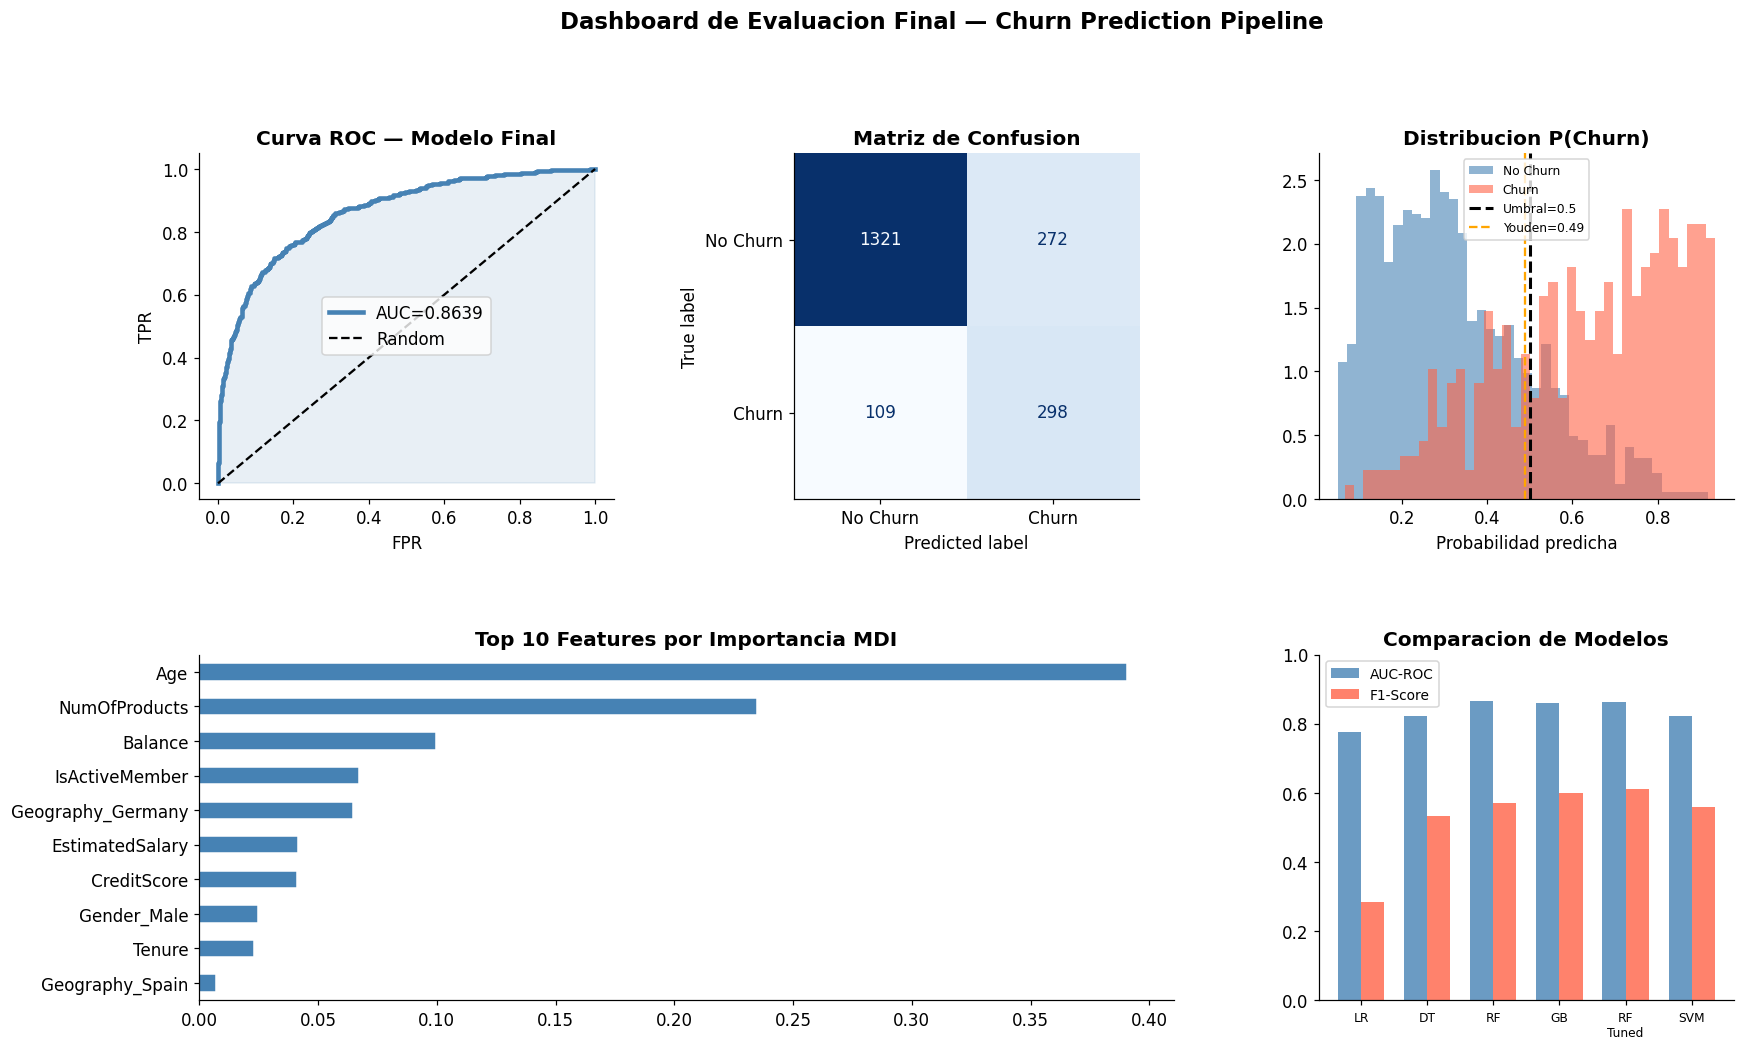

In [54]:
# --- Dashboard de evaluacion final ---
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ROC
ax_roc = fig.add_subplot(gs[0, 0])
ax_roc.plot(fpr_fin, tpr_fin, color='steelblue', lw=3, label=f'AUC={auc_final:.4f}')
ax_roc.fill_between(fpr_fin, tpr_fin, alpha=0.12, color='steelblue')
ax_roc.plot([0,1],[0,1],'k--',lw=1.5, label='Random')
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
ax_roc.set_title('Curva ROC — Modelo Final', fontweight='bold')
ax_roc.legend()

# Confusion Matrix
ax_cm = fig.add_subplot(gs[0, 1])
cm_fin = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm_fin, display_labels=['No Churn', 'Churn']).plot(
    ax=ax_cm, colorbar=False, cmap='Blues')
ax_cm.set_title('Matriz de Confusion', fontweight='bold')

# Distribucion de probabilidades
ax_prob = fig.add_subplot(gs[0, 2])
ax_prob.hist(y_proba_final[y_test==0], bins=40, alpha=0.6, color='steelblue',
             label='No Churn', density=True)
ax_prob.hist(y_proba_final[y_test==1], bins=40, alpha=0.6, color='tomato',
             label='Churn', density=True)
ax_prob.axvline(0.5, color='black', ls='--', lw=2, label='Umbral=0.5')
best_thr = thrs_fin[np.argmax(tpr_fin - fpr_fin)]
ax_prob.axvline(best_thr, color='orange', ls='--', lw=1.5, label=f'Youden={best_thr:.2f}')
ax_prob.set_title('Distribucion P(Churn)', fontweight='bold')
ax_prob.set_xlabel('Probabilidad predicha'); ax_prob.legend(fontsize=8)

# Feature importance
ax_fi = fig.add_subplot(gs[1, 0:2])
rf_m_prod = final_model_prod.named_steps['clf']
ohe_feats_prod = final_model_prod.named_steps['prep'].named_transformers_['cat']['ohe'].get_feature_names_out(cat_cols).tolist()
feat_names_prod = num_cols + ohe_feats_prod + bin_cols
fi_prod = pd.Series(rf_m_prod.feature_importances_, index=feat_names_prod).sort_values()
fi_prod.tail(10).plot(kind='barh', ax=ax_fi, color='steelblue', edgecolor='white')
ax_fi.set_title('Top 10 Features por Importancia MDI', fontweight='bold')

# Comparacion de modelos
ax_cmp = fig.add_subplot(gs[1, 2])
models_final = ['LR', 'DT', 'RF', 'GB', 'RF\nTuned', 'SVM']
aucs_final   = [
    auc(fpr_lr, tpr_lr),
    auc(fpr_dt, tpr_dt),
    auc(fpr_rf, tpr_rf),
    auc(fpr_gb, tpr_gb),
    auc_final,
    auc(fpr_svm, tpr_svm),
]
f1s_final    = [
    f1_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_gb),
    f1_final,
    f1_score(y_test, y_pred_svm),
]
x_cmp = np.arange(len(models_final)); w_cmp = 0.35
bars_a = ax_cmp.bar(x_cmp-w_cmp/2, aucs_final, w_cmp, label='AUC-ROC', color='steelblue', alpha=0.8)
bars_f = ax_cmp.bar(x_cmp+w_cmp/2, f1s_final,  w_cmp, label='F1-Score', color='tomato',    alpha=0.8)
ax_cmp.set_xticks(x_cmp); ax_cmp.set_xticklabels(models_final, fontsize=8)
ax_cmp.set_ylim([0, 1.0]); ax_cmp.set_title('Comparacion de Modelos', fontweight='bold')
ax_cmp.legend(fontsize=9)

plt.suptitle('Dashboard de Evaluacion Final — Churn Prediction Pipeline',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('final_dashboard.png', bbox_inches='tight')
plt.show()


In [55]:
# --- Serializacion y funcion de scoring para produccion ---
with open('churn_model_pipeline.pkl', 'wb') as f:
    pickle.dump(final_model_prod, f)

metrics_prod = {
    'model': 'RandomForest (class_weight=balanced)',
    'auc_roc':     round(float(auc_final),  4),
    'f1_score':    round(float(f1_final),   4),
    'accuracy':    round(float(acc_final),  4),
    'cv_auc_mean': round(float(cv_auc_prod.mean()), 4),
    'cv_auc_std':  round(float(cv_auc_prod.std()),  4),
    'n_train': int(len(X_train)),
    'n_test':  int(len(X_test)),
    'features': list(X.columns),
}
with open('model_metrics.json', 'w') as f:
    json.dump(metrics_prod, f, indent=2)

print("Archivos guardados:")
print("  churn_model_pipeline.pkl  — pipeline serializado (preprocessor + modelo)")
print("  model_metrics.json        — metricas de evaluacion")
print()
print(json.dumps(metrics_prod, indent=2))


# --- Funcion de scoring para produccion ---
def predict_churn(customer_data: dict,
                  model_path: str = 'churn_model_pipeline.pkl',
                  threshold: float = 0.5) -> dict:
    '''
    Funcion de scoring de produccion.

    Args:
        customer_data: dict con los campos del cliente
        model_path:    ruta al pickle del pipeline entrenado
        threshold:     umbral de decision (default 0.5)

    Returns:
        dict con prediccion, probabilidad y nivel de riesgo
    '''
    with open(model_path, 'rb') as f:
        model = pickle.load(f)

    df_input = pd.DataFrame([customer_data])

    # El pipeline maneja TODO el preprocessing automaticamente
    pred_proba = float(model.predict_proba(df_input)[0, 1])
    pred_class = int(pred_proba >= threshold)
    risk_level = ('ALTO' if pred_proba > 0.7 else
                  'MEDIO' if pred_proba > 0.4 else 'BAJO')

    return {
        'churn_prediction': pred_class,
        'churn_probability': round(pred_proba, 4),
        'risk_level': risk_level,
        'threshold_used': threshold,
    }


# --- Ejemplos de uso ---
print("=" * 50)
print("  EJEMPLOS DE SCORING EN PRODUCCION")
print("=" * 50)

casos = [
    {'desc': 'Cliente alto riesgo',
     'data': {'CreditScore': 550, 'Geography': 'Germany', 'Gender': 'Female',
              'Age': 48, 'Tenure': 1, 'Balance': 180000.0, 'NumOfProducts': 1,
              'HasCrCard': 0, 'IsActiveMember': 0, 'EstimatedSalary': 75000.0}},
    {'desc': 'Cliente bajo riesgo',
     'data': {'CreditScore': 800, 'Geography': 'France', 'Gender': 'Male',
              'Age': 35, 'Tenure': 8, 'Balance': 50000.0, 'NumOfProducts': 2,
              'HasCrCard': 1, 'IsActiveMember': 1, 'EstimatedSalary': 120000.0}},
]

for caso in casos:
    res = predict_churn(caso['data'])
    print(f"\n  Perfil: {caso['desc']}")
    print(f"  Churn predicho:     {res['churn_prediction']}")
    print(f"  Probabilidad churn: {res['churn_probability']:.1%}")
    print(f"  Nivel de riesgo:    {res['risk_level']}")


Archivos guardados:
  churn_model_pipeline.pkl  — pipeline serializado (preprocessor + modelo)
  model_metrics.json        — metricas de evaluacion

{
  "model": "RandomForest (class_weight=balanced)",
  "auc_roc": 0.8639,
  "f1_score": 0.61,
  "accuracy": 0.8095,
  "cv_auc_mean": 0.8575,
  "cv_auc_std": 0.0124,
  "n_train": 8000,
  "n_test": 2000,
  "features": [
    "CreditScore",
    "Geography",
    "Gender",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary"
  ]
}
  EJEMPLOS DE SCORING EN PRODUCCION

  Perfil: Cliente alto riesgo
  Churn predicho:     1
  Probabilidad churn: 83.7%
  Nivel de riesgo:    ALTO

  Perfil: Cliente bajo riesgo
  Churn predicho:     0
  Probabilidad churn: 7.4%
  Nivel de riesgo:    BAJO


In [ ]:
# --- Resumen ejecutivo final ---
summary_final = pd.DataFrame({
    'Modelo':        ['Logistic Reg.', 'Decision Tree', 'Random Forest',
                      'Gradient Boost', 'RF (Tuned)', 'SVM'],
    'AUC-ROC':       [round(auc(fpr_lr,  tpr_lr),  4),
                      round(auc(fpr_dt,  tpr_dt),  4),
                      round(auc(fpr_rf,  tpr_rf),  4),
                      round(auc(fpr_gb,  tpr_gb),  4),
                      round(auc_final,              4),
                      round(auc(fpr_svm, tpr_svm), 4)],
    'F1-Score':      [round(f1_score(y_test, y_pred_lr),  4),
                      round(f1_score(y_test, y_pred_dt),  4),
                      round(f1_score(y_test, y_pred_rf),  4),
                      round(f1_score(y_test, y_pred_gb),  4),
                      round(f1_final,                     4),
                      round(f1_score(y_test, y_pred_svm), 4)],
    'Accuracy':      [round(accuracy_score(y_test, y_pred_lr),  4),
                      round(accuracy_score(y_test, y_pred_dt),  4),
                      round(accuracy_score(y_test, y_pred_rf),  4),
                      round(accuracy_score(y_test, y_pred_gb),  4),
                      round(acc_final,                          4),
                      round(accuracy_score(y_test, y_pred_svm), 4)],
    'Interpretable': ['SI', 'SI', 'PARCIAL', 'NO', 'PARCIAL', 'NO'],
    'Escala (big n)':['SI', 'SI', 'SI',      'SI', 'SI',      'NO'],
    'Requiere scaler':['SI','NO', 'NO',       'NO', 'NO',      'SI'],
}).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)

print("=" * 82)
print("  RESUMEN FINAL — TODOS LOS MODELOS")
print("=" * 82)
print(summary_final.to_string(index=False))
print()
print("Mejor modelo global:     RF Tuned  (mejor AUC + buen F1)")
print("Mas interpretable:       Logistic Regression o Decision Tree")
print("Mas rapido en produccion:Logistic Regression")
print("Estado del arte tabular: XGBoost / LightGBM")
print()
print("Para el caso de churn bancario (FN mas costoso que FP):")
print("-> Bajar el umbral de 0.5 a ~0.35-0.40 para maximizar Recall")


---
## Referencias y Recursos

### Libros fundamentales (todos con PDF libre)
- **James, Witten, Hastie, Tibshirani (2023)** — *Introduction to Statistical Learning (ISL)*
  FREE: https://www.statlearning.com
- **Hastie, Tibshirani, Friedman (2009)** — *Elements of Statistical Learning (ESL)*
  FREE: https://web.stanford.edu/~hastie/ElemStatLearn
- **Bishop (2006)** — *Pattern Recognition and Machine Learning* — el clasico teorico

### Cursos
- **Stanford CS-229** (Andrew Ng) — https://cs229.stanford.edu
- **Cheat Sheet CS-229** — https://stanford.edu/~shervine/l/es/teaching/cs-229/
- **fast.ai Practical Deep Learning** — https://www.fast.ai

### Herramientas del ecosistema
```python
xgboost / lightgbm  — gradient boosting estado del arte para datos tabulares
catboost            — manejo nativo de categoricas, muy robusto
optuna              — hyperparameter optimization bayesiana (reemplaza GridSearch)
shap                — Shapley values para interpretabilidad de cualquier modelo
mlflow              — experiment tracking y model registry
evidently           — monitoreo de data drift y performance en produccion
imbalanced-learn    — SMOTE, ADASYN para datos desbalanceados
```

### Proximos pasos en el programa
1. **SHAP values** — explicabilidad global y local de modelos black-box
2. **Imbalanced learning** — SMOTE, class_weight, threshold tuning
3. **Stacking y Blending** — meta-learners para combinar modelos
4. **Feature engineering** avanzado — interacciones, target encoding, embeddings
5. **Deep Learning** — redes neuronales, PyTorch, transformers (BERT, RoBERTa)
6. **Causal ML** — CATE, DML, DiD, IV — crucial para economia aplicada

---
> Notebook elaborado para la clase de Maestria en Economia Aplicada — ITAM
> Datasets: Churn_Modelling (clasificacion), Advertising (regresion), tweets (NLP)
